 # How to Run
1. Begin by setting the granularity to 'q'. (change the accessed element in the list to 0)
2. Set run_every_query to True
3. Update max_quarter and max_month
4. Run All
5. Set the granularity to 'm'. (change the accessed element in the list to 1)
6. Set run_every_query to False and build_ms_df_from_scratch to True
7. Restart Kernel and Run All

In [1]:
import pandas as pd
import numpy as np
import pyodbc
import pickle
import warnings
import time
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
tqdm.pandas()
pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 100)
import openpyxl
import datetime as dt
import re
import os
import copy
#git comment test

In [2]:
granularity = ['q', 'm','w'][2]
run_every_query = True
use_legacy_ms_query = True  # If False, derive ms_df from ula_df_total instead of running postmodern_ms_query
max_quarter, max_month = 1, 2
max_week = dt.date.today().strftime("%U")
max_week = int(max_week)

# Date column configuration: weekly uses app_date, quarterly/monthly uses book_date
use_app_date_vintage = (granularity == 'w')  # Weekly uses app_date
date_col = 'app_date' if use_app_date_vintage else 'book_date'

# Weekly runs only from 2024 onwards to reduce runtime
min_date = "'2024-01-01'" if use_app_date_vintage else "'2016-01-01'"
start_year = 2024 if use_app_date_vintage else 2016

In [3]:
def vintage_to_float(vintage):
    """
    Converts a vintage of form 'YYYY QQ' (i.e. '2016 Q2') to a float (i.e. 2016.25)
    The vectorized form of this function for a Series is: pd.to_numeric(df.vintage.str[:4]) + (pd.to_numeric(df.vintage.str[-1]) - 1) / 4
    NOTE: The following formula has been modified to allow for vintages of the form 'YYYY MMM' (i.e. '2016 M06')
    """
    if vintage[5]=='Q':
        return int(vintage[:4]) + (int(vintage[-1]) - 1) / 4
    elif vintage[5]=='M':
        return int(vintage[:4]) + (int(vintage[-2:]) - 1) / 12
    

def float_to_vintage(vintage_float):
    """
    Converts a vintage as a float (i.e. 2016.25) to a str of form 'YYYY QQ' (i.e. '2016 Q2')
    The vectorized form of this function for a Series is: 
        df.vintage_float.astype(int).astype(str) + ' Q' + ((df.vintage_float % 1) * 4 + 1).astype(int).astype(str)
    """
    return str(int(vintage_float)) + ' Q' + str(int((vintage_float % 1) * 4 + 1))
    
"""
SQL and Files
"""
def run_sql(filename, sub_list=[], connection=None, filename_is_query=False):
    """
    Run a SQL Query by reading from a .txt file, substituting values when required.
    Input:
    filename (str): File that we want to read. Usually a .txt file.
    sub_list (list of (str,str) tuples): Substitute each instance of the first element of the tuple for the second.
                                         Example: [('{max_mob}', '6')]
    """
    if filename_is_query:
        query = filename
    else:
        with open(filename, 'r') as file:
            query = file.read()
    for sub in sub_list:
        text, var = sub
        query = query.replace(text, var)
#     print(query)
    if connection is None:
        with pyodbc.connect("DSN=Redshift_prod_new") as conn:
            warnings.filterwarnings("ignore", category=UserWarning)
            df = pd.read_sql_query(sql=query, con=conn)
            warnings.filterwarnings("default", category=UserWarning)
            return df
    else:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=connection)
        warnings.filterwarnings("default", category=UserWarning)
        return df

def store_pickle(data, filename):
    """
    Stores a pickle of the given data at the given filename, in a simplified function call
    """
    # Perform a swap if I got the order of data and filename backwards
    if type(data)==str:
        temp = filename
        filename = data
        data = temp
    with open(filename, 'wb') as file:
        pickle.dump(data, file)

def get_pickle(filename):
    """
    Loads a pickle in a simplified function call
    """
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    return data

def smooth(series):
    """
    Calculates a centered average by averaging the previous two values and following two values, as well as the current value.
    Handles the first and last two values separately.
    """
    averaged_series = pd.Series(index=series.index, dtype=float)  # Create an empty Series to store the averaged values
    
    # Handle the first value separately
    averaged_series.iloc[0] = series.iloc[0]
    averaged_series.iloc[1] = (series.iloc[0] + series.iloc[1] + series.iloc[2]) / 3
    
    # Calculate the running average for the middle values
    for i in range(2, len(series) - 2):
        averaged_series.iloc[i] = (series.iloc[i-2] + series.iloc[i-1] + series.iloc[i] + series.iloc[i+1] + series.iloc[i+2]) / 5
    
    # Handle the last value separately
    averaged_series.iloc[-1] = series.iloc[-1]
    averaged_series.iloc[-2] = (series.iloc[-1] + series.iloc[-2] + series.iloc[-3]) / 3
    
    return averaged_series
def weight_by_proceeds(metric, proceeds):
    """
    Function to get the average of a given Series, weighted by Amount Financed.
    """
    return (metric * proceeds).sum() / proceeds.sum()
def weighted_average_and_sum(group, metrics):
    """
    Function that gets the weighted average of a Series (or several series), 
        returning the averages and the sum of Amount Financed.
    """
    if type(metrics)==str:
        weighted_avg = (group[metrics] * group.amt_financed).sum() / group.amt_financed.sum()
        return pd.Series({metrics: weighted_avg, 'amt_financed': group.amt_financed.sum()})
    result_dict = {'amt_financed': group.amt_financed.sum()}
    for metric in metrics:
        weighted_avg = (group[metric] * group.amt_financed).sum() / group.amt_financed.sum()
        # result_dict[metric] = weighted_avg.sum()
        result_dict[metric] = weighted_avg

    return pd.Series(result_dict)

# Old Recovery Model

In [4]:
def auc_pred(rra_df, leave_out, rra_lob_df=None):
    """
    Recovery model used by the pricing team to determine the expected recovery of a vehicle when it is sold.
    KMX uses a different recovery model, so it's handled separately.
    This function was made to support "Leave Out" analysis, which isn't included in the Ragu jar. 
        That's what all the if/else statements are for.
    This function has been vectorized as much as possible, but it's possibly not totally optimized.
    Inputs:
        rra_df (pd.DataFrame object): Data containing vehicle info. Each row is a vehicle, and each row is analyzed separately.
        leave_out (str): Factor to not consider in this runthrough. Helps us understand how much of a role each factor plays.
        rra_lob_df (pd.DataFrame): Only used in Leave Out analysis. Contains every vehicle for every vintage for this LOB.
    Outputs:
        recovery_multiplier (pd.Series): Column to add to rra_df containing the % of original vehicle value we expect to recover.
    """
    if len(rra_df[rra_df.lob=='KMX']) > 0:
        conditions = [
            (rra_df.car_age_orig < 3),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig == 3) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price >= 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price < 30000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price >= 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig >= 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price >= 40000)
        ]

        values = [3300, 3700, 5400, 7200, 4700, 6400, 8200, 5700, 7400, 9200]

        recovery_amount = np.maximum(0, rra_df.sale_price - np.select(conditions, values, default=0))

        return recovery_amount * (1 - 0.206) ** rra_df.yob / rra_df.sale_price


    rra_df['coef_intercept'] = 0.0891185245
    rra_df['coef_yob'] = -0.2668087106 * rra_df.yob


    if leave_out != 'Mileage/age':
        rra_df['coef_mlg_x_age'] = 0.0001463508 * rra_df.car_age_orig * rra_df.mileage - 0.0004310013 * rra_df.car_age_orig - 0.0033127224 * rra_df.mileage
    else: 
        rra_df['coef_mlg_x_age'] = np.log((np.exp(0.0001463508 * rra_lob_df.car_age_orig * rra_lob_df.mileage) * np.exp(-0.0004310013 * rra_lob_df.car_age_orig) * np.exp(-0.0033127224 * rra_lob_df.mileage)).mean())
    if leave_out != 'Japanese':
        rra_df['coef_japanese'] = rra_df.car_japanese.map({'Japanese': 0.1004702010, 'Other': 0})
    else:
        rra_df['coef_japanese'] = np.log(rra_lob_df.car_japanese.map({'Japanese': np.exp(0.1004702010), 'Other': np.exp(0)}).mean())
    if leave_out != 'Vehicle class':
        rra_df['coef_class'] = rra_df.car_class_only.map({'Compact': 0.0303893787,
                                        'Minivan': np.log(0.975),
                                        'Sporty': 0.0758593720,
                                        'SUV Large': -0.0237364286,
                                        'SUV Small': 0.0190370746,
                                        'Work Van': 0,
                                        'Truck': 0.1436074633,
                                        'Car': 0, 'Other':0})
    else:
        rra_df['coef_class'] = np.log(rra_lob_df.car_class_only.map({'Compact': np.exp(0.0303893787),
                                                             'Minivan': np.exp(np.log(0.975)),
                                                             'Sporty': np.exp(0.0758593720),
                                                             'SUV Large': np.exp(-0.0237364286),
                                                             'SUV Small': np.exp(0.0190370746),
                                                             'Work Van': np.exp(0),
                                                             'Truck': np.exp(0.1436074633),
                                                             'Car': np.exp(0), 'Other':np.exp(0)}).mean())
    if leave_out != 'Fuel type':
        rra_df['coef_fuel'] = rra_df.fuel_type.map({'Hybrid': -0.0315481529,
                                       'Flex': 0.0255682747,
                                       'Diesel': -0.1284314925,
                                       'EV': np.log(0.9),
                                       'Gas': 0})
    else:
        rra_df['coef_fuel'] = np.log(rra_lob_df.fuel_type.map({'Hybrid': np.exp(-0.0315481529),
                                                    'Flex': np.exp(0.0255682747),
                                                    'Diesel': np.exp(-0.1284314925),
                                                    'EV': np.exp(np.log(0.9)),
                                                    'Gas': np.exp(0)}).mean())
    if leave_out != 'Luxury classification':
        rra_df['coef_lux'] = rra_df.car_lux.map({'Luxury': -0.1108317813, 'Standard': 0})
    else:
        rra_df['coef_lux'] = np.log(rra_lob_df.car_lux.map({'Luxury': np.exp(-0.1108317813), 'Standard': np.exp(0)}).mean())
    if leave_out != 'LOB':
        rra_df['coef_lob'] = rra_df.lob.map({'ENT': 0.0405731662,
                                      'FLD': 0.0405731662,
                                      'FRN': -0.0277901296,
                                      'STG': 0.0263749504,
                                      'AN': 0})
    else:
        rra_df['coef_lob'] = np.log(rra_lob_df.lob.map({'ENT': np.exp(0.0405731662),
                                              'FLD': np.exp(0.0405731662),
                                              'FRN': np.exp(-0.0277901296),
                                              'STG': np.exp(0.0263749504),
                                              'AN': np.exp(0)}).mean())
    if leave_out != 'Driver flag':
        rra_df['coef_driver'] = (-0.0918049638) * rra_df.driver_flag
    else:
        rra_df['coef_driver'] = np.log(rra_lob_df.driver_flag.map({1:np.exp(-0.0918049638), 0: np.exp(0)}).mean())
    if leave_out != 'Impound probability':
        rra_df['coef_impound'] = (-0.2803330880) * rra_df.impound_prob
    else:
        rra_df['coef_impound'] = np.log(np.mean(np.exp((-0.2803330880) * rra_lob_df.impound_prob)))
    
    try:
        # code that may raise an exception

        rra_df=rra_df.dropna()
        for col in ['coef_intercept', 'coef_yob', 'coef_mlg_x_age', 'coef_japanese', 'coef_class', 'coef_fuel', 'coef_lux', 
                    'coef_lux', 'coef_lob', 'coef_driver', 'coef_impound']:
            # print(col)
            assert len(rra_df)==len(rra_df.dropna(subset=col))
    except Exception as e:
        # code to handle the exception
        print(col, ';', rra_df.fuel_type.unique())
        print(len(rra_df) - len(rra_df.fuel_type.dropna()))
        print(rra_df)
        store_pickle('rra_df_pickle_exception',rra_df)
        raise Exception()

    return rra_df.r_mmi * np.exp(rra_df.coef_intercept + rra_df.coef_yob + rra_df.coef_mlg_x_age + rra_df.coef_japanese\
                                 + rra_df.coef_class + rra_df.coef_fuel + rra_df.coef_lux + rra_df.coef_lob\
                                 + rra_df.coef_impound + rra_df.coef_driver)

In [5]:
def get_ula_multiplier_nonkmx(ula_df, leave_out):

    ula_df['loss_multiplier'] = 1


    # print(ula_df.loss_multiplier.mean())


    if leave_out !='Previous ACA chargeoff':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.prev_co_flag # loss_adj_01_acaco: 1 or 1.1

    # print("Previous ACA chargeoff: " + str(ula_df.prev_co_flag.mean()))
    # print(ula_df.loss_multiplier.mean())


    if leave_out!='Small amount financed':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.small_amt_financed_flag *(1- ula_df.pricing_change_flag) # loss_adj_02_small_amtfin: 1 or 1.1

    # print("small atf: " + str(ula_df.small_amt_financed_flag.mean()))
    # print(ula_df.loss_multiplier.mean())


    if leave_out!='Zero cash down':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.zero_cash_down_flag * (1 - ula_df.pricing_change_flag) # loss_adj_03_zero_down: 1 or 1.1

    # print("zero cd: " + str(ula_df.zero_cash_down_flag.mean()))
    # print(ula_df.loss_multiplier.mean())



    if leave_out!='High mileage vehicle':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_mileage_vehicle_flag # loss_adj_04_high_mileage: 1 or 1.1


    # print("high miles: " + str(ula_df.high_mileage_vehicle_flag.mean()))
    # print(ula_df.loss_multiplier.mean())


    if leave_out!='High PTI':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_pti_flag * (1 - ula_df.pricing_change_flag) # loss_adj_05_high_PTI: 1 or 1.1


    # print("high pti: " + str(ula_df.high_mileage_vehicle_flag.mean()))
    # print(ula_df.loss_multiplier.mean())


    if leave_out!='Car make':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.car_make_penalty_flag\
                                    - 0.1 * ula_df.car_make_benefit_flag - 0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag
                                    #+  0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag*ula_df.ent_fld_flag # loss_adj_06_vehicle_make: 1 or 0.9 or 1.1

    # print("toyho: " + str(ula_df.car_make_benefit_flag.mean()))
    # print(ula_df.loss_multiplier.mean())

    if leave_out!='Theft risk':
        ula_df.loss_multiplier *= 0.987 + 0.099 * ula_df.theft_risk_flag * (1-ula_df.pricing_change_flag) + 0.013*ula_df.pricing_change_flag  # loss_adj_09_theft_risk: 0.987 or 1.086

    # print("theft risk: " + str(ula_df.theft_risk_flag.mean()))
    # print(ula_df.loss_multiplier.mean())

    if leave_out!='MCY high model score, low mileage':
        ula_df.loss_multiplier *= 1 - 0.2 * ula_df.mcy_low_mileage_flag # loss_adj_07_new_MCY: 1 or 0.8
    if leave_out!='Weekday/weekend decision':
        ula_df.loss_multiplier *= 1 - 0.05 * ula_df.weekend_flag\
                                    + 0.02 * ula_df.weekday_flag # loss_adj_08_day_of_week: 1 or 0.95 or 1.02

    #
    #
    # print(ula_df.loss_multiplier)
    # print("pre everything")


         # MS - 130 for all LOB's except ENT where it's MS - 128
    if leave_out!='Student Loans':
        ula_df.loss_multiplier *= 1 + (0.1 * ula_df.student_loan_flag \
                                            - np.minimum( np.maximum( (ula_df.cd_model_score - (130 - 2 * ula_df.ent_flag)) * 0.006, 0 ), 0.03) * (1 - ula_df.student_loan_flag))*(ula_df.student_loans_cutoff_date)




    #
    # print(ula_df.loss_multiplier)
    # print("student loans")

    if leave_out != 'Low PTI':
        # print(ula_df.loss_multiplier)
        ula_df.loss_multiplier *= 1 + (-0.03 * np.minimum(ula_df.cd_model_score, 135) + 3.9) * ula_df.low_pti_flag



    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loss_multiplier *= 0.966 + 0.273 * ula_df.nonkmx_chime_flag
        #ula_df.loss_multiplier *= 0.989 + 0.111 * ula_df.secured_credit_flag # loss_adj_10_secured_card: 0.989 or 1.1

    # print("chime")
    # print(ula_df.loss_multiplier.mean())

    # print("chime counts: " + str(ula_df.nonkmx_chime_flag.count()))
    # print("chime avg: " + str(ula_df.nonkmx_chime_flag.mean()))
    # print(ula_df.loss_multiplier.mean())


    if leave_out!='Employment type':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.seasonal_employment_flag\
                                    - 0.1 * ula_df.waiter_employment_flag # loss_adj_11_employment: 1 + 0.1 * cust_attr$employment_flag
    if leave_out!='Authorized tradelines':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.nonkmx_auth_tradelines_flag # loss_adj_13_authorized_tradeline: 1 or 1.1


    if leave_out != 'Fraud':
        ula_df.loss_multiplier *= 1  + (ula_df.fraud_adjustment -1)



    if leave_out != 'Driver flag':
        ula_df.loss_multiplier *= 1 + 0.15 * ula_df.driver_flag



    if leave_out!='Clip':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.8, 2) #previously (0.8,1.2)
    #if leave_out!='Null FICO with Vantage':
        #ula_df.loc[ula_df['fico_adjustment_flag'] == 1, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag # loss_adj_14_non_fico: 0.99 or 1.1
    if leave_out!='Dealer Level (Non-KMX)':
        ula_df.loss_multiplier *= ula_df.pricing_scalar
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.7, 1.4) #previously (0.8,1.2)
    # if leave_out!='Dealer Level (Non-KMX)':
    #     ula_df.loss_multiplier *= 1 - 0.2 * (ula_df.lob_or_bucket == 'A').astype(int) \
    #                                 - 0.1 * (ula_df.lob_or_bucket == 'B').astype(int) \
    #                                 + 0.09 * (ula_df.lob_or_bucket == 'D').astype(int) \
    #                                 + 0.2 * (ula_df.lob_or_bucket == 'E').astype(int)
        #change for lob dll ragu
    # The following is a pricing adjustment, but we don't include it, since it's macroeconimic (that's what the loss committee predicts)
#       #Additional loss adjustment to ensure losses match loss committe predictions
#   lob_scalar <- ifelse(app_attr$lob == "AN", 1.045,
#                        ifelse(app_attr$lob == "FLD", 1.09,
#                               ifelse(app_attr$lob == "FRN", 0.925,
#                                      ifelse(app_attr$lob == "STG", 0.996, 1))))



    return ula_df

In [6]:
def get_ula_multiplier_kmx(ula_df, loss_scale=0.067, leave_out='None'):
    ula_df['loss_multiplier'] = 1.0




    # if leave_out!='Job time':
    #     # 0.99 counter
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag

    if leave_out!='Low FICO':
        # remove
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_fico_flag & ula_df.high_model_score_flag)


    if leave_out!='Low Vantage':

        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_vantage_flag & ula_df.high_model_score_flag)

    # if leave_out!='Louisiana':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.35 * ula_df.louisiana_flag

    if leave_out!='High PTI':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0 * ula_df.normal_pti_flag \
                                    + 0.05 * ula_df.high_pti_tier_1_flag \
                                    + 0.1 * ula_df.high_pti_tier_2_flag \
                                    + (1.4 * (1 + loss_scale) - 1) * ula_df.high_pti_tier_3_flag
   
   
   
    # if leave_out!='Existing DQ':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.1 * ula_df.existing_dq_flag
    # if leave_out!='Employment type':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] /= (1 + loss_scale)



    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + (-0.01 + 0.06 * ula_df.secured_credit_flag)\
                                        * ~(~ula_df.job_time_flag & ula_df.narrowed_soft_pull_flag & ula_df.secured_credit_flag)

    if leave_out!='Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.18 * ula_df.kmx_auth_tradelines_flag
   
   
    # if leave_out!='Null FICO with Vantage':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag + 0.01 * ula_df.null_fico_null_vantage_flag
    
    
    if leave_out!='Soft pull':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + ~ula_df.job_time_flag * (~ula_df.narrowed_soft_pull_flag * -0.025)  + ula_df.narrowed_soft_pull_flag * (~ula_df.secured_credit_flag * 0.108)








    if leave_out!='Clip': #verified
        clipped_multiplier = np.clip(ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'], 0.8, 1.35 / (1 + loss_scale))

        ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'] = clipped_multiplier


        # clipped_multiplier = np.clip(ula_df[~ula_df.high_pti_tier_3_flag].loss_multiplier, 0.8, 1.35 / (1 + loss_scale))
        #
        # ula_df.loc[~ula_df.high_pti_tier_3_flag & ~ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier






    if leave_out!='Vehicle Age':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier']  *= 0.8593 + 0.0201 * ula_df.continuous_vehicle_age


    #Mountain 3.1 Gross Loss Adjustments
    # MTN 3.2 is exactly the same as 3.1


    # add low vantage to 3.1: vantage 5-475, if soft pull then 1.1x counter 0.99, no soft pull 1.2x v 0.98, NA no adjustment

    # 3.1: cash down % penalty:
    # add npc flag, every loan using npc, if pti > 0.2 then penalty is 1.1x and 0.99
    # student loans: if pb or cb has student stu loans, 1.1x and 0.96 counter
    #driver flag, 1.15x no counter, use same determination as nonkmx





    #4.1 has adjustment for >30k sales price. 1.15,  counter is 0.97
    #everything in 3.1 is also in 4.1 + the sales price


    if leave_out !='npc':
        ula_df.loc[ula_df.kmx_npc_flag, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.high_pti_npc




    if leave_out != 'Student Loans':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.96 +  0.14 * ula_df.student_loan_flag




    if leave_out != 'high sales price':
        ula_df.loc[ula_df.mtn_model.isin([4.1]),'loss_multiplier'] *= 0.98 + 0.22 * ula_df.high_sales_price_flag


    if leave_out != 'Driver flag':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + 0.15 * ula_df.driver_flag






    if leave_out!='Louisiana':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier']  *= 1 + 0.35 * ula_df.louisiana_flag
        # print(in )

    if leave_out!='georgia':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier']  *= 1 + 0.1 * ula_df.georgia_flag

    if leave_out!='txca':
        # MS > 140 get 0.9 benefit, 135-140 get 0.95 benefit
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score > 140) ,'loss_multiplier']  *= 1 - 0.1 * ula_df.txca_flag
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score <= 140) &  (ula_df.cd_model_score >= 135)   ,'loss_multiplier']  *= 1 - 0.05 * ula_df.txca_flag


    if leave_out!='state_counter_adj':
        ula_df.loc[ ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1])  & (ula_df.cd_model_score < 150) & ~(ula_df.louisiana_flag | ula_df.georgia_flag | ula_df.txca_flag) ,'loss_multiplier'] *= 1.012
    
    
    if leave_out!='Secured credit (Chime, etc.)': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.96 + (0.01 * ula_df.soft_pull_flag  - 0.18*ula_df.chime_flag* ula_df.soft_pull_flag) + 0.46*ula_df.chime_flag

    if leave_out!='Job time': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag

    if leave_out!='Existing DQ': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.11 * ula_df.existing_dq_flag

    if leave_out!='Employment type': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag





    if leave_out!='Authorized tradelines': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.06 * ula_df.kmx_auth_tradelines_flag




    if leave_out!='Soft pull': #verified

        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag,'loss_multiplier'] *= 1.1  * (0.99 + 0.11*ula_df.low_bureau_flag) * (0.97 + 0.15*ula_df.cd_perc_flag) * (0.978 + 0.172*ula_df.open_tl_flag)
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ~ula_df.soft_pull_flag,'loss_multiplier'] *= (1 * (0.98 + 0.22*ula_df.low_bureau_flag)* (0.954 + 0.346*ula_df.cd_perc_flag)  * (0.945 + 0.405*ula_df.open_tl_flag ) /np.maximum(ula_df.cd_perc_flag*ula_df.open_tl_flag*1.2,1)) #verified





    if leave_out!='low MS decline rule1':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2]),'loss_multiplier'] *= 1 + 0.2 * ula_df.sub130msflag
        

    if leave_out!='low MS decline rule2': # this is the one with vehicle age
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + 0.15 * ula_df.sub140msflag

    if leave_out!='low MS decline rule3':
        ula_df.loc[ula_df.mtn_model.isin([4.1]),'loss_multiplier'] *= 1 + 0.2 * ula_df.sub135msflag
        
        #sylvia: 135 in 4.1 is closer to 130 in 3.x models
        




                                                                                                          # verified
 #verified
  



    # if leave_out!='Soft pull':
    #     ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag,'loss_multiplier'] *= 1.1 * (0.97 + 0.23*ula_df.secured_credit_flag) * (0.995 + 0.03*ula_df.low_bureau_flag) * (0.97 + 0.15*ula_df.cd_perc_flag) * (0.978 + 0.172*ula_df.open_tl_flag)
    #     ula_df.loc[ula_df.mtn_3_1_flag & ~ula_df.soft_pull_flag,'loss_multiplier'] *= 1 * (0.98 + 0.32*ula_df.secured_credit_flag) * (0.9767 + 0.2233*ula_df.low_bureau_flag)* (0.954 + 0.346*ula_df.cd_perc_flag) * (0.945 + 0.405*ula_df.open_tl_flag )/np.maximum(ula_df.cd_perc_flag*ula_df.open_tl_flag*1.2,1)

    # ula_df.loc[ula_df.mtn_3_1_flag,'loss_multiplier']/=1.1

    # print(f"DEBUG: cd_perc_flag mean = {ula_df.cd_perc_flag.mean():.6f}, open_tl_flag mean = {ula_df.open_tl_flag.mean():.6f}")
    # print(f"DEBUG: MTN 3.1 mean after soft_pull = {ula_df.loc[ula_df.mtn_model == 3.1, 'loss_multiplier'].mean():.6f}")

    if leave_out!='Clip':

        # verified, use the same clip for 4.1
        # clipped_multiplier = np.clip(ula_df[ula_df.mtn_3_1_flag].loss_multiplier, 0.75, 1.4)
        # ula_df.loc[ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier



        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] = np.clip(ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'], 0.75, 1.4)


    # for model in [3.0, 3.1, 3.2, 4.1]:
    #     mean_val = ula_df.loc[ula_df.mtn_model == model, 'loss_multiplier'].mean()
    #     print(f"mtn_model {model}: mean loss_multiplier = {mean_val}")






    # if leave_out!='Car make':
    #     ula_df.loss_multiplier *= 1 - 0.08*ula_df.kmx_toyho_flag
    #
    return ula_df

## Fetch MS

In [7]:
"""
Refetch the original model scores, untainted by any modification by analysis.
If use_legacy_ms_query is False, ms_df will be derived from ula_df_total later (after it's loaded).
"""
if use_legacy_ms_query:
    run_query = False
    if run_query or run_every_query:
        all_original_model_scores = run_sql('postmodern_ms_query.txt', sub_list=[('{min_book_date}', min_date)])
        store_pickle(all_original_model_scores, 'all_original_model_scores_pickle')
    else:
        all_original_model_scores = get_pickle('all_original_model_scores_pickle')
    all_original_model_scores[date_col] = all_original_model_scores[date_col].astype(str)
    all_original_model_scores.book_week = all_original_model_scores.book_week.astype(str)
    all_original_model_scores.app_week = all_original_model_scores.app_week.astype(str)
    #print(all_original_model_scores[date_col])
    if granularity == 'q':
        all_original_model_scores['vintage'] = all_original_model_scores[date_col].str[:4] + ' Q' + ((all_original_model_scores[date_col].str[5:7].astype(int) - 1) // 3 + 1).astype(str)
    elif granularity == 'm':
        all_original_model_scores['vintage'] = all_original_model_scores[date_col].str[:4] + ' M' + all_original_model_scores[date_col].str[5:7]
    else:
        all_original_model_scores['vintage'] = all_original_model_scores[date_col].str[:4] + '-'+ all_original_model_scores.app_week.str.zfill(2)
        
    original_model_scores = all_original_model_scores.groupby(['vintage', 'lob']).apply(weighted_average_and_sum, 'model_score').reset_index()
    original_model_scores = pd.concat([original_model_scores, all_original_model_scores.groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('POS')
    original_model_scores = pd.concat([original_model_scores, all_original_model_scores[all_original_model_scores.lob.isin(['AN', 'STG', 'FRN', 'FLD'])].groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('non_kmxent')
    ms_df = original_model_scores.copy()
else:
    print('Skipping legacy ms_query - ms_df will be derived from ula_df_total')

In [8]:
if use_legacy_ms_query:
    display(ms_df.head())
else:
    print('ms_df will be available after ula_df_total is loaded')

,vintage,lob,model_score,amt_financed
0,2023-44,FRN,139.000000,10040.80
1,2023-44,STG,132.000000,16277.68
2,2023-45,ENT,134.078943,51666.88
3,2023-45,KMX,121.000000,26883.40
4,2023-45,STG,133.000000,14542.70


In [9]:
def get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, new_recovery, leave_out='None'):
    """
    This function provides the core of RAGU Score analysis.
    There are three parts to this code:
        1. Get Unit Loss Adjustments: Modify the probability of chargeoff based on factors not included in Model Score.
        2. Get Recovery Rate Adjustments: Use auc_pred() to calculate how much we'll recover if the vehicle sells.
        3. Group it all together: Group based on granularity, applying the RAGU Score calculation formulas (see PowerPoint).
            This section rolls up by LOB, but if there are multiple LOBs (for non_kmxent), group by that in addition.
    Inputs:
        vintage (str): Monthly or quarterly vintage (for example, "2022 M03" or "2022 Q1") we want results for
        lob (str or tuple of str): LOB we want results for.
            If multiple are provided, they are assessed in the context of each other, but still separate.
        lob_type (str): Higher-order group. For KMX and ENT, this is the same as LOB, but for other LOBs, this is 'non_kmxent'
        ula_df_total (pd.DataFrame object): DataFrame containing every vehicle's ULA-related info throughout ACA history.
        rra_df_total (pd.DataFrame object): DataFrame containing every vehicle's RRA-related info throughout ACA history.
        leave_out (str): For Leave Out analysis, what factor to leave out. This helps us assess how much impact each factor has.
    Outputs:
        full_df (pd.DataFrame): DataFrame containing the results of RAGU Score analysis for the given vintage and LOB(s).
            All columns are weighted averages unless otherwise noted.
            Columns: 'amt_financed_x': Sum of amount financed for this grouping
                     'loss_multiplier': Result of ULA.  What % more or less the unit loss rate should be.
                     'recovery_unadjusted_multiplier': % of original vehicle value we expect to recover, not adjusted for LTV or baseline.
                     'ltv': LTV of grouping
                     'bbvalue': BlackBook value of grouping. For KMX, this is sale price instead.
                     'ltv_realization_factor': Unused. Factor to determine how much benefit from LTV we're seeing.
                     'recovery_100_ltv_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, assuming 100% impact.
                     'recovery_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, after ltv_realization_factor.
                     'vintage': Vintage for this grouping.
                     'model_score': Model score for this grouping. Same as ms_original.
                     'amt_financed_y': Unused. Sum of amount financed for this grouping, using different parts of ms_df. Nearly the same as amt_financed_x.
                     'est_unit_loss': Probability of chargeoff. Currently set to mean_unit_loss. We may eventually modify this to convert the Unit Loss Score to a Unit Loss %.
                     'unit_loss_score': Model Score adjusted for ULA.
                     'ms_original': Model score for this grouping. Same as model_score (for the moment, this may change when we get better historical values for the current model).
                     'baselined_recovery': recovery_multiplier / baseline_recovery_pct. How much better/worse we're doing for this grouping compared to the grouping's baseline.
                     'baselined_unadjusted_recovery': recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct
                     'baselined_100_ltv_recovery': recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct
                     'ms_gla': Renamed Unit Loss Score
                     'ms_exclude_ltv': RAGU Score without any LTV impacts. Because we have some issues with LTV, this is the score we use, taking LTV adjustments in the Excel.
                     'ms_100_ltv': RAGU Score assuming 100% LTV impacts.
                     'ragu_score': RAGU Score using baselined_recovery. Uses the RAGU formulas.
    """
    # Get the Unit Loss Adjustment Multiplier
    if type(lob)==str:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob==lob)].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob==lob)].copy()
    else:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob.isin(lob))].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob.isin(lob))].copy()


    if lob == 'KMX':
        loss_scale = 0.067
        ula_df = get_ula_multiplier_kmx(ula_df, loss_scale, leave_out)
    else:
        ula_df = get_ula_multiplier_nonkmx(ula_df, leave_out)
    ula_df = ula_df[['account_number', date_col, 'bbvalue', 'sale_price', 'amt_financed', 'lob_or_bucket', 'lob', 'loss_multiplier']]



    # Get the Recovery Rate Adjustment Multiplier
    if leave_out == 'None':
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob==lob)].copy()
            new_rec = new_recovery[(new_recovery.vintage==vintage)&(new_recovery.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob.isin(lob))].copy()
            new_rec = new_recovery[(new_recovery.vintage==vintage)&(new_recovery.lob.isin(lob))].copy()
    else:
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.lob==lob)].copy()
            new_rec = new_recovery[(new_recovery.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.lob.isin(lob))].copy()
            new_rec = new_recovery[(new_recovery.lob.isin(lob))].copy()

    try:
        rra_df.car_year = rra_df.car_year.fillna(round(rra_df.car_year.mean()))
    except:
        store_pickle('rra_df_pickle_exception',rra_df)
    # Note: ceil(car_age_orig) = ula_df's vehicle_age column
    rra_df['car_age_orig'] = np.maximum((pd.to_datetime(rra_df[date_col]) - pd.to_datetime(rra_df.car_year.astype(int).astype(str) + '-09-01')).dt.days / 365, 1 / 365)



    rra_df = rra_df.merge(new_recovery[['account_number', 'new_recovery_multiplier']],
                      on='account_number',
                      how='left')


    if leave_out == 'None':
        # rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out)
        rra_df['recovery_multiplier'] = rra_df['new_recovery_multiplier']
    else:
        rra_lob_df = rra_df.copy()
        rra_df = rra_df[rra_df.vintage==vintage]
        # rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out, rra_lob_df)
        rra_df['recovery_multiplier'] = rra_df['new_recovery_multiplier']


    rra_df = rra_df[['account_number', 'recovery_multiplier']]
    mix_df = ula_df.merge(rra_df, on='account_number', how='inner').drop_duplicates(subset='account_number', keep='first')
    bb_populated_df = mix_df.dropna(subset='bbvalue')
    bb_populated_df['ltv'] = bb_populated_df.amt_financed / bb_populated_df.bbvalue
    # bb_populated_df['recovery_unadjusted_multiplier'] = rra_df['recovery_multiplier']   #skip_rate * bb_populated_df.recovery_multiplier.copy()
    bb_populated_df['recovery_unadjusted_multiplier'] = bb_populated_df['recovery_multiplier'].copy()


    # DEBUG: Compare with diagnostic output
    # print(f"ula_df count: {len(ula_df)}  rra_df count: {len(rra_df)}")
    # print(f'bb_pop count: {len(bb_populated_df)}')
    # print(f"bb_pop amtfin: {bb_populated_df['amt_financed'].sum():,.2f}")
    # print(f"bb_pop mean mult: {bb_populated_df['loss_multiplier'].mean():.6f}")
    # print(f"bb_pop mult*atf sum: {(bb_populated_df['loss_multiplier'] * bb_populated_df['amt_financed']).sum():,.2f}")
    # print(f"bb_pop wtd mult: {(bb_populated_df['loss_multiplier'] * bb_populated_df['amt_financed']).sum() / bb_populated_df['amt_financed'].sum():.6f}")
    # Group by LOB
    # bb_populated_df.reset_index()

    grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])

    # print( "grouped amtfin: "  +     str(grouped_mix_df['amt_financed'].sum()))

    # print( "grouped post wtd mult: "  +     str(grouped_mix_df['loss_multiplier'].mean()))



    # bb_populated_df.reset_index()

    # Calculate these values after rollup to match the LTV graph better.
    grouped_mix_df['ltv_realization_factor'] = 0 # 1 - ltv_realization_dollar / (grouped_mix_df.recovery_unadjusted_multiplier * grouped_mix_df.bbvalue)
    grouped_mix_df['recovery_100_ltv_multiplier'] = 0 # (grouped_mix_df.recovery_unadjusted_multiplier * baseline_ltv / grouped_mix_df.ltv).copy()
    grouped_mix_df['recovery_multiplier'] = 0 # grouped_mix_df.recovery_unadjusted_multiplier * (1 + (baseline_ltv / grouped_mix_df.ltv - 1) * grouped_mix_df.ltv_realization_factor)
    vintage_ms_df = ms_df[ms_df.vintage==vintage].copy()
    #store_pickle('vintage_ms_df_keyerror', vintage_ms_df)
    #store_pickle('grouped_mix_df_keyerror', grouped_mix_df)

    #wrapp

    # vintage_ms_df = vintage_ms_df.reset_index(drop = True) #revert to original, remove line

    # grouped_mix_df = grouped_mix_df.reset_index(drop = False) #revert to original, remove line



    index_name = grouped_mix_df.index.name
    if type(index_name) == str and index_name in grouped_mix_df.columns:
    # 'lob' already exists as a column; don't re-insert it
        grouped_mix_df = grouped_mix_df.reset_index(drop=True)
    else:
        grouped_mix_df = grouped_mix_df.reset_index()




    full_df = grouped_mix_df.merge(vintage_ms_df, on='lob')



    full_df['est_unit_loss'] = mean_unit_loss
    full_df['unit_loss_score'] = full_df.model_score + (1 - full_df.loss_multiplier) * full_df.est_unit_loss / unit_loss_to_model_score
    full_df = full_df.set_index('lob')
    # Step 1: Get Model Score
    full_df['ms_original'] = full_df.model_score.copy()
    # Step 2: Adjust Model Score by Pricing Adjustments (This includes Unit Loss and pre-LTV Recovery adjustments)
    full_df['baselined_recovery'] = 0 # (full_df.recovery_multiplier / baseline_recovery_pct).copy()
    # full_df['baselined_unadjusted_recovery'] = (full_df.recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct).copy()

    full_df['baselined_unadjusted_recovery'] = (full_df.recovery_unadjusted_multiplier / new_baseline_recovery_unadjusted_pct).copy()


    full_df['baselined_100_ltv_recovery'] = 0 # (full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct).copy()


    if type(lob) != str and len(lob) > 1:
        full_df.loc[lob_type, 'unit_loss_score'] = weight_by_proceeds(full_df.unit_loss_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'est_unit_loss'] = mean_unit_loss
        full_df.loc[lob_type, 'ms_original'] = weight_by_proceeds(full_df.model_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_recovery'] = weight_by_proceeds(full_df.recovery_multiplier / baseline_recovery_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_unadjusted_recovery'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier / new_baseline_recovery_unadjusted_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_100_ltv_recovery'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_multiplier'] = weight_by_proceeds(full_df.recovery_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_unadjusted_multiplier'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_100_ltv_multiplier'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'vintage'] = vintage
        full_df.loc[lob_type, 'ltv'] = weight_by_proceeds(full_df.ltv, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'amt_financed_x'] = full_df.amt_financed_x.sum()


    full_df['ms_gla'] = full_df.unit_loss_score.copy()
    full_df['ms_exclude_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier * full_df.unit_loss_score * full_df.baselined_unadjusted_recovery

    full_df['only_recovery_ragu'] = full_df['ms_exclude_ltv'] - full_df['ms_gla']

    full_df['ms_100_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier * full_df.unit_loss_score * full_df.baselined_100_ltv_recovery
    # Step 3: RAGU Score
    full_df['ragu_score'] = (1 - full_df.est_unit_loss * full_df.recovery_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_multiplier * full_df.unit_loss_score * full_df.baselined_recovery


    return full_df

# Fetch ula_df_total, rra_df_total

In [10]:
"""
The following block of code establishes ula_df_total and rra_df_total, as well as some standard assumptions.
The SQL query takes a very long time (30+ minutes), since it's a series of temp tables and gets every single loan.
All the calculations after the query should be vectorized, speeding up the process.
"""
expected_years_on_book = 2
impound_probability = 0.15
mmi_standard_increase = 1.03
run_query = False
generate_dfs = True
if generate_dfs:
    if run_query or run_every_query:
        with pyodbc.connect("DSN=Redshift_prod_new") as conn:
            with open("establish_temp_tables_query.txt", "r") as file:
                temp_table_queries = file.read()
            # conn.execute(temp_table_queries.strip())


            # run_sql('establish_temp_tables_query.txt', connection=conn)

        with pyodbc.connect("DSN=Redshift_prod_new") as conn:

            print('temptables finished')
            
            ula_df_total = run_sql('vintage_level_ula_query.txt', sub_list=[('{min_book_date}', min_date)], connection=conn)
            print('ula query finished')

            rra_df_total = run_sql('vintage_level_rra_query.txt', sub_list=[('{min_book_date}', min_date)], connection=conn)
            dla_df = run_sql('new_dll_query.txt', connection = conn)
            print('tables query finished')

            new_recovery =  run_sql('new_recovery_queryt.txt', connection=conn)
            print('new recovery finished')





        store_pickle((ula_df_total, rra_df_total,dla_df), '(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    else:
        ula_df_total, rra_df_total, dla_df = get_pickle('(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    # Make DataFrame-wide changes
    rra_df_total = rra_df_total[rra_df_total.lob != 'Core'] # Core Model Scores are missing
    ula_df_total = ula_df_total[ula_df_total.lob != 'Core'] # Core Model Scores are missing
    
    #MTN 3.1 flag
    ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
    ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
    #ula_df_total['mtn_3_1_flag'] = ula_df_total.app_date>= pd.to_datetime("2024-12-16")
    ula_df_total['mtn_3_1_flag'] = ula_df_total.mtn_model== 'MTN3.1'

    rra_df_total[date_col] = rra_df_total[date_col].astype(str)
    new_recovery[date_col] = new_recovery[date_col].astype(str)
    ula_df_total[date_col] = ula_df_total[date_col].astype(str)

    rra_df_total.book_week = rra_df_total.book_week.astype(str)
    new_recovery.book_week = new_recovery.book_week.astype(str)
    ula_df_total.book_week = ula_df_total.book_week.astype(str)
    rra_df_total.app_week = rra_df_total.app_week.astype(str)
    new_recovery.app_week = new_recovery.app_week.astype(str)
    ula_df_total.app_week = ula_df_total.app_week.astype(str)


    ula_df_total['vehicle_age'] = np.maximum(ula_df_total[date_col].str[:4].astype(int) - ula_df_total.model_year, 1/365)
    ula_df_total.tradein_value = ula_df_total.tradein_value.fillna(0)
    ula_df_total.make = ula_df_total.make.str.upper().str[:3]
    ula_df_total.lob_or_bucket = np.select([ula_df_total.lob_or_bucket.isna() & ula_df_total.lob.isin(['Core', 'FRN']),
                                          ula_df_total.lob_or_bucket.isna() & ~ula_df_total.lob.isin(['Core', 'FRN'])], 
                                         ['D', 'C'], default=ula_df_total.lob_or_bucket)
    ula_df_total['continuous_vehicle_age'] = ula_df_total[date_col].str[:4].astype(int) + ula_df_total[date_col].str[5:7].astype(int)/12 - (ula_df_total.model_year - 0.25) - 1
   
    #Dealer Level Loss DLL
    dla_df =dla_df.rename(columns={"valid_vintage": "book_vintage"})
    #dla_df = dla_df.replace("current","2025 Q2")

    ula_df_total = ula_df_total.replace("2026 Q1","current")
    #ula_df_total = ula_df_total.replace("2024 Q4","current")
    ula_df_total = pd.merge(ula_df_total, dla_df, how="left", on=['dealer_number','book_vintage'])

    ula_df_total = ula_df_total.replace("current", "2026 Q1")


    ula_df_total['pricing_scalar'] = ula_df_total['pricing_scalar'].fillna(1)
    
    ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar'] = ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar']*1.05
    ula_df_total.loc[ula_df_total.frni_flag==0,'pricing_scalar'] = ula_df_total.loc[ula_df_total.frni_flag==0,'pricing_scalar']*0.95

    
    rra_df_total['yob'] = expected_years_on_book # df['MOB'] / 12    
    rra_df_total['impound_prob'] = impound_probability
    rra_df_total.car_make = rra_df_total.car_make.str.upper()
    rra_df_total['car_class_only'] = np.select([rra_df_total.vehicle_class.str.contains('Pickup', na=False),
                                          rra_df_total.vehicle_class.str.contains('Sporty', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Large.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Minivan', na=False),
                                          rra_df_total.vehicle_class.str.contains(' Van', na=False)],
                                         ['Truck', 'Sporty', 'Compact', 'Car', 'SUV Small', 'SUV Large', 'Minivan', 'Work Van'],
                                         default='Other')
    rra_df_total.fuel_type = np.select([rra_df_total.fuel_type.str.contains('Electric|Plug|EV', na=False),
                                        rra_df_total.fuel_type.str.contains('Hyb', na=False),
                                        ((rra_df_total.fuel_type=='CNG')|(rra_df_total.fuel_type=='LPG')),
                                        ((rra_df_total.fuel_type=='null')|(rra_df_total.fuel_type==None))],
                                 ['EV', 'Hybrid', 'Gas', 'Gas'],
                                 default=rra_df_total.fuel_type)
    rra_df_total['car_lux'] = np.where((rra_df_total.vehicle_class.str.contains('Luxury', na=False)), 'Luxury', 'Standard')
    rra_df_total['car_japanese'] = np.where(rra_df_total.car_make.isin(['HONDA', 'ACURA', 'ISUZU', 'MAZDA', 'MITSUBISHI', 'SUZUKI', 'TOYOTA', 'LEXUS', 'SCION', 'TOYOYA']),
                                     'Japanese', 'Other')
#     rra_df_total['job_clean'] = # TODO: Part of new recovery model
    warnings.filterwarnings("ignore", category=UserWarning)
    rra_df_total.job_company = rra_df_total.job_company.fillna('not provided')
    rra_df_total['driver_flag'] = np.where(rra_df_total.job_company.str.contains('(LYFT)|(UBER)|(GRUB ?HUB)|(DOOR ?DASH)|(GO ?PUFF)|(POST ?MATE)|(INSTA ?CART)|(DOMINO)|(PAPA J)|(PIZZA)|(JIMMY ?JOHN)|(SELF)'),
                                     1, 0)

    #add RRA's driver flag column to ula 10/23/2025
    ula_df_total = ula_df_total.merge (rra_df_total[['account_number', 'driver_flag']] ,  on='account_number', how='left')


    warnings.filterwarnings("default", category=UserWarning)
    rra_df_total['mileage'] = rra_df_total.mileage_orig / 1000
    rra_df_total['r_mmi'] = mmi_standard_increase ** rra_df_total.yob
    # Handle NA values
    ula_df_total = ula_df_total.dropna(subset=['sale_price', 'cd_model_score', 'pti', 'lob'])
    ula_df_total.cash_down = ula_df_total.cash_down.fillna(0)
    ula_df_total.employment = ula_df_total.employment.fillna('not seasonal or waiter')
    ula_df_total.specialty_dealer = ula_df_total.specialty_dealer.fillna('not specialty')
    ula_df_total.prev_co_count = ula_df_total.prev_co_count.fillna(0)
    # Fill flags (non_fld_non_kmx, non_fld_an_stg_frn)
    # non_fld_non_kmx <- app_attr$lob %in% c("AN", "STG", "FRN", "MCY", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_a'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'MCY', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_non_kmx", even though FLD is included.
    # dealer_attr$non_fld_fixed <- ifelse(!is.na(dealer_attr$specialty_dealer) && (tolower(dealer_attr$specialty_dealer) %in% c('non-fld fixed 1') | (tolower(dealer_attr$specialty_dealer) %in% c("non-fld fixed 2") && app_attr$a_b_call == "A")), 1, 0)

    # non_fld_an_stg_frn <- app_attr$lob %in% c("AN", "STG", "FRN", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_b'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_an_stg_frn", even though it's actually non-KMX, non-MCY.
    ##---Populate Flags---#
    # NonKMX Flags
    ula_df_total['ent_fld_flag'] = (ula_df_total.lob=='ENT') | (ula_df_total.lob=='FLD')
    ula_df_total['small_amt_financed_flag'] = (ula_df_total.bbvalue < 5000) & (ula_df_total.amt_financed < 4500) & (ula_df_total.lob != 'MCY')
    ula_df_total['zero_cash_down_flag'] = (ula_df_total.cash_down <= 250) & (ula_df_total.tradein_value < 3000)
    ula_df_total['high_mileage_vehicle_flag'] = (ula_df_total.mileage >= 100000) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY')
    ula_df_total['high_pti_flag'] = (ula_df_total.pti > 0.3) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_penalty_flag'] = ula_df_total.make.isin({'CAD', 'CHR', 'BMW', 'BUI', 'SUB'}) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_benefit_flag'] = (ula_df_total.cd_model_score >= 133) & ula_df_total.make.isin({'HON', 'TOY', 'LEX'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['theft_risk_flag'] = ula_df_total.make.isin({'KIA', 'HYU'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally') & (ula_df_total.model_year >= 2015) & (ula_df_total.model_year <= 2021) & (ula_df_total[date_col] >= '2022-07-01')
    ula_df_total['mcy_low_mileage_flag'] = (ula_df_total.lob == 'MCY') & (ula_df_total.cd_model_score > 140) & (ula_df_total.mileage <= 20000) & (ula_df_total.vehicle_age <= 10)
    ula_df_total['weekend_flag'] = ula_df_total.day_of_week.isin([0,6])
    ula_df_total['weekday_flag'] = ula_df_total.day_of_week.isin(range(1,6))
    ula_df_total['secured_credit_flag'] = ula_df_total.secured_credit_card
    ula_df_total['chime_flag'] = ula_df_total.chime_indicator # | ula_df_total.secured_credit_card
    ula_df_total['nonkmx_chime_flag'] = ula_df_total.nonkmx_chime_indicator
    ula_df_total['seasonal_employment_flag'] = ula_df_total.employment == 'seasonal'
    ula_df_total['waiter_employment_flag'] = ula_df_total.employment == 'waiter'
    ula_df_total['high_cash_down_echopark_flag'] = False # Removed, only ever implemented as a test
    ula_df_total['nonkmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines > 0.2
    ula_df_total['prev_co_flag'] = ula_df_total.prev_co_count > 0
    ula_df_total['null_fico_w_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & (ula_df_total.vantage_score >= 300) & (ula_df_total.vantage_score <= 850)
    ula_df_total['null_fico_null_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & ((ula_df_total.vantage_score < 300) | (ula_df_total.vantage_score > 850))
    ula_df_total['pricing_change_flag'] = ula_df_total[date_col] >= '2024-10-01'



    ula_df_total['ent_flag'] = (ula_df_total.lob == 'ENT')
    ula_df_total['student_loans_cutoff_date'] = ula_df_total[date_col] >= '2023-05-01'
    ula_df_total['low_pti_flag'] = (ula_df_total.pti <= 0.05) & (ula_df_total.cd_model_score >= 130) & ula_df_total.lob.isin({'AN', 'FLD', 'FRN', 'STG'}) & (ula_df_total.cb_flag)
    ula_df_total['student_loan_flag'] = np.where(ula_df_total.student_loan_flag == 1, 1, 0)



    # KMX Flags
    #high sales price flag for mtn4.1
    ula_df_total['high_sales_price_flag'] = ula_df_total.sale_price > 30000
    
    ula_df_total['kmx_npc_flag'] = ula_df_total.kmx_npc_flag == 1
    ula_df_total['high_pti_npc'] = ula_df_total.pti > 0.2

    ula_df_total['job_time_flag'] = ula_df_total.employed_months < 6
    ula_df_total['low_fico_flag'] = (ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 450)
    ula_df_total['high_model_score_flag'] = ula_df_total.cd_model_score >= 146
    ula_df_total['low_vantage_flag'] = (ula_df_total.fico_score < 300) & (ula_df_total.vantage_score > 4) & (ula_df_total.vantage_score < 450)
    ula_df_total['louisiana_flag'] = ula_df_total.state == 'LA'
    ula_df_total['txca_flag'] = ula_df_total.state.isin(['TX', 'CA'])
    ula_df_total['georgia_flag'] = ula_df_total.state == 'GA'

    ula_df_total['normal_pti_flag'] = ula_df_total.pti <= 0.2
    ula_df_total['high_pti_tier_1_flag'] = (ula_df_total.pti > 0.2) & (ula_df_total.pti <= 0.25)
    ula_df_total['high_pti_tier_2_flag'] = (ula_df_total.pti > 0.25) & (ula_df_total.pti <= 0.35)
    ula_df_total['high_pti_tier_3_flag'] = ula_df_total.pti > 0.35
    ula_df_total['existing_dq_flag'] = ula_df_total.existing_dq_count > 0
    #Existing DQ Flag already in df
    ula_df_total['kmx_toyho_flag'] = ula_df_total.cd_model_score>=130 & ula_df_total.make.isin({'HON', 'TOY'})
    ula_df_total['kmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines >= 0.14
    ula_df_total['low_bureau_flag'] = ((ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 475)) | (ula_df_total.vantage_score > 4) & ((ula_df_total.vantage_score < 450))
    ula_df_total['soft_pull_flag'] = ula_df_total.pull_type == 'softpull'
    ula_df_total['cd_perc_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1)
    ula_df_total['open_tl_flag'] = ula_df_total.open_tl = 0 
    ula_df_total['narrowed_soft_pull_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1) & ula_df_total.soft_pull_flag & (~ula_df_total.job_time_flag)

    ula_df_total['sub130msflag'] = ula_df_total.cd_model_score <= 130
    ula_df_total['sub135msflag'] = (ula_df_total.cd_model_score <= 135) & (ula_df_total.amt_financed_front >= 23000)


    ula_df_total['sub140msflag'] = ((ula_df_total.cd_model_score <= 140) & (ula_df_total.vehicle_age <= 3) & (~ula_df_total.sub130msflag))




    # Add in vintages
    if granularity == 'q':
        rra_df_total['vintage'] = rra_df_total[date_col].str[:4] + ' Q' + ((rra_df_total[date_col].str[5:7].astype(int) - 1) // 3 + 1).astype(str)
        ula_df_total['vintage'] = ula_df_total[date_col].str[:4] + ' Q' + ((ula_df_total[date_col].str[5:7].astype(int) - 1) // 3 + 1).astype(str)
        new_recovery['vintage'] = new_recovery[date_col].str[:4] + ' Q' + ((new_recovery[date_col].str[5:7].astype(int) - 1) // 3 + 1).astype(str)
    elif granularity == 'm':
        rra_df_total['vintage'] = rra_df_total[date_col].str[:4] + ' M' + rra_df_total[date_col].str[5:7]
        ula_df_total['vintage'] = ula_df_total[date_col].str[:4] + ' M' + ula_df_total[date_col].str[5:7]
        new_recovery['vintage'] = new_recovery[date_col].str[:4] + ' M' + new_recovery[date_col].str[5:7]
    elif granularity == 'w':
        rra_df_total['vintage'] = rra_df_total[date_col].str[:4] + '-' + rra_df_total.app_week.str.zfill(2)
        ula_df_total['vintage'] = ula_df_total[date_col].str[:4] + '-' + ula_df_total.app_week.str.zfill(2)
        new_recovery['vintage'] = new_recovery[date_col].str[:4] + '-' + new_recovery.app_week.str.zfill(2)
    # Many customers have multiple jobs. This creates many duplicates. Condense the flags down:
    ula_df_total = ula_df_total.drop_duplicates().copy()
    ula_df_total['employment_type_code'] = ula_df_total.seasonal_employment_flag * 1 + ula_df_total.waiter_employment_flag * 8
    combined_employment_code_df = ula_df_total.groupby('account_number').employment_type_code.sum().reset_index()
    ula_df_total = ula_df_total.drop(columns='employment_type_code').merge(combined_employment_code_df, on='account_number')
    ula_df_total.seasonal_employment_flag = (ula_df_total.employment_type_code == 1) | (ula_df_total.employment_type_code == 9)
    ula_df_total.waiter_employment_flag = (ula_df_total.employment_type_code == 8) | (ula_df_total.employment_type_code == 9)
    ula_df_total = ula_df_total.drop(columns='employment').drop_duplicates()
    # Do the same for rra_df_total
    combined_driver_flag_df = rra_df_total.groupby('account_number').driver_flag.max().reset_index()
    rra_df_total = rra_df_total.drop(columns='driver_flag').merge(combined_driver_flag_df, on='account_number')
    rra_df_total = rra_df_total.drop(columns='job_company').drop_duplicates()
    store_pickle((ula_df_total, rra_df_total), '(ula_df_total, rra_df_total)_refined_pickle')
else:
    ula_df_total, rra_df_total = get_pickle('(ula_df_total, rra_df_total)_refined_pickle')

# Build ms_df from ula_df_total if not using legacy query
if not use_legacy_ms_query:
    # Derive model scores from the same BB-valued population used in ULA calculations
    # Using vectorized aggregation instead of groupby().apply() for performance
    ms_source = ula_df_total[['lob', 'cd_model_score', 'amt_financed', 'vintage']].copy()
    ms_source = ms_source.rename(columns={'cd_model_score': 'model_score'})
    
    # Precompute weighted values (vectorized)
    ms_source['weighted_score'] = ms_source['model_score'] * ms_source['amt_financed']
    
    # Aggregation by vintage and LOB (vectorized - much faster than apply)
    by_vintage_lob = ms_source.groupby(['vintage', 'lob']).agg(
        weighted_score_sum=('weighted_score', 'sum'),
        amt_financed=('amt_financed', 'sum')
    ).reset_index()
    by_vintage_lob['model_score'] = by_vintage_lob['weighted_score_sum'] / by_vintage_lob['amt_financed']
    original_model_scores = by_vintage_lob[['vintage', 'lob', 'model_score', 'amt_financed']]
    
    # Portfolio-level ('POS') aggregation
    by_vintage_pos = ms_source.groupby(['vintage']).agg(
        weighted_score_sum=('weighted_score', 'sum'),
        amt_financed=('amt_financed', 'sum')
    ).reset_index()
    by_vintage_pos['model_score'] = by_vintage_pos['weighted_score_sum'] / by_vintage_pos['amt_financed']
    by_vintage_pos['lob'] = 'POS'
    original_model_scores = pd.concat([original_model_scores, by_vintage_pos[['vintage', 'lob', 'model_score', 'amt_financed']]])
    
    # non_kmxent aggregation (AN, STG, FRN, FLD)
    non_kmxent_source = ms_source[ms_source.lob.isin(['AN', 'STG', 'FRN', 'FLD'])]
    by_vintage_nonkmx = non_kmxent_source.groupby(['vintage']).agg(
        weighted_score_sum=('weighted_score', 'sum'),
        amt_financed=('amt_financed', 'sum')
    ).reset_index()
    by_vintage_nonkmx['model_score'] = by_vintage_nonkmx['weighted_score_sum'] / by_vintage_nonkmx['amt_financed']
    by_vintage_nonkmx['lob'] = 'non_kmxent'
    original_model_scores = pd.concat([original_model_scores, by_vintage_nonkmx[['vintage', 'lob', 'model_score', 'amt_financed']]])
    
    ms_df = original_model_scores.copy()
    print(f'ms_df derived from ula_df_total: {len(ms_df)} rows')

temptables finished
ula query finished
tables query finished
new recovery finished


In [11]:
scratch_df = ula_df_total.loc[ula_df_total['frni_flag']==-1] #quarterly

In [12]:
# ula_df_total['car_make_benefit_flag'].mean()
# ula_df_total['car_make_penalty_flag'].mean()
# ula_df_total['low_pti_flag'].mean()
# ula_df_total['null_fico_null_vantage_flag'].mean()
# ula_df_total= ula_df_total[ula_df_total['fraud_adjustment'] != 1]

# ula_df_total['fraud_adjustment'].mean()
# scratch_df.head()

In [13]:
filtered_df = ula_df_total[(ula_df_total['chime_flag'] == 1) & (ula_df_total['nonkmx_chime_flag'] == 0)]
print(filtered_df)

Empty DataFrame
Columns: [account_number, book_date, book_week, app_week, book_vintage, app_date, bbvalue, dealer_number, sale_price, frni_flag, amt_financed, amt_financed_front, cash_down, tradein_value, mileage, cd_model_score, total_income, pti, make, model_year, vin, lob, day_of_week, secured_credit_card, chime_indicator, nonkmx_chime_indicator, student_loan_flag, cb_flag, fraud_adjustment, job_company, specialty_dealer, employed_months, fico_score, vantage_score, state, pull_type, existing_dq_count, pct_auth_tradelines, open_tl, prev_co_count, lob_or_bucket, apr_bucket, fico_adjustment_flag, mtn_model, kmx_npc_flag, mtn_3_1_flag, vehicle_age, continuous_vehicle_age, dll_edition, loss_ratio, dealer_level, pricing_scalar, driver_flag, dealer_filter_a, dealer_filter_b, ent_fld_flag, small_amt_financed_flag, zero_cash_down_flag, high_mileage_vehicle_flag, high_pti_flag, car_make_penalty_flag, car_make_benefit_flag, theft_risk_flag, mcy_low_mileage_flag, weekend_flag, weekday_flag, sec

In [14]:
#scratch_df.to_csv('ula_df_total_current_dla_2.csv')

In [15]:
#rra_df_total.head() #monthly
# grouped_mix_df.head()


In [16]:
# grouped_mix_df

In [17]:
"""
Wrapper for the RAGU Score calculations.
Baselines and other standard assumptions are established here.
Also groups by POS once everything is done, though we don't really look at POS.
"""
all_df_no_dropout = None
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle',
#                    'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision',
#                    'Secured credit (Chime, etc.)',hi
#
#                    'Employment type', 'High cash down EchoPark', 'Authorized tradelines',
#                    'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type',
#                    'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                    'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
leave_out_list = ['None']
full_df_list_dict_dict = dict()
for leave_out in leave_out_list:
    # print(leave_out)
    # Run all vintages
    available_vintages_dict = {'non_kmxent': list(ms_df[ms_df.lob.isin(['FRN', 'STG', 'AN', 'FLD'])].vintage.unique()),
                          'ENT': list(ms_df[ms_df.lob == 'ENT'].vintage.unique()),
                          'KMX': list(ms_df[ms_df.lob == 'KMX'].vintage.unique())}
    full_df_list_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    vintages_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    baseline_ltv_dict = {'non_kmxent': 1.94, 'ENT': 1.45, 'KMX': 1.5863}
    baseline_recovery_unadjusted_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.46, 'KMX': 0.3546}
    new_baseline_recovery_unadjusted_pct_dict = {'non_kmxent': 0.55, 'ENT': 0.54, 'KMX': 0.58}
    baseline_recovery_100_ltv_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    baseline_recovery_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    mmi_standard_increase = 1.03
    expected_years_on_book = 2
    impound_probability = 0.15
    mean_unit_loss = 0.5
    unit_loss_to_model_score = 0.02
    skip_rate = 0.75 # Not actually skip rate, should be % of CO sold
    ltv_realization_dollar = 0
    for lob, lob_type in zip([('FRN', 'AN', 'STG', 'FLD'), 'ENT', 'KMX'],
                             ['non_kmxent', 'ENT', 'KMX']):
        available_vintages = available_vintages_dict[lob_type]
        baseline_ltv = baseline_ltv_dict[lob_type]
        baseline_recovery_pct = baseline_recovery_pct_dict[lob_type]
        baseline_recovery_unadjusted_pct = baseline_recovery_unadjusted_pct_dict[lob_type]
        new_baseline_recovery_unadjusted_pct = new_baseline_recovery_unadjusted_pct_dict[lob_type]

        baseline_recovery_100_ltv_pct = baseline_recovery_100_ltv_pct_dict[lob_type]
        for year in range(start_year, 2027): #weekly starts 2024, else 2016
            if granularity == 'q':
                sub_year_list = range(1, 5)
            elif granularity == 'm':
                sub_year_list = range(1, 13)
            else:
                sub_year_list = range(1,53)
            for sub_year in sub_year_list:
                if year==2026 and ((granularity=='q' and sub_year > max_quarter) or (granularity=='m' and sub_year > max_month) or(granularity=='w' and sub_year > max_week)):
                    continue
                if granularity == 'm' or granularity == 'w':
                    sub_year = str(sub_year).zfill(2)
                if granularity == 'q':
                    vintage = f"{year} Q{sub_year}"
                elif granularity == 'm':
                    vintage = f"{year} M{sub_year}"
                else:
                    vintage = f"{year}-{sub_year}"
                if vintage in ('2022 M02', '2023 M11','2022-05','2022-06','2022-07','2022-08','2022-09','2023-44','2023-45','2023-46','2023-47','2023-48') and lob=='KMX':
                    continue
                if vintage in ('2023-14','2023-15') and lob_type in ('non_kmxent','ENT'):
                    continue
                if vintage in vintages_dict[lob_type] or vintage not in available_vintages:
                    continue
                print(vintage, lob)
                full_df = get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, new_recovery, leave_out=leave_out)
                if type(lob)==str:
                    if lob in full_df_list_dict.keys():
                        full_df_list_dict[lob].append(full_df)
                        vintages_dict[lob].append(vintage)
                    else:
                        full_df_list_dict[lob] = [full_df]
                        vintages_dict[lob] = [vintage]
                else:
                    if lob_type in full_df_list_dict.keys():
                        full_df_list_dict[lob_type].append(full_df)
                        vintages_dict[lob_type].append(vintage)
                    else:
                        full_df_list_dict[lob_type] = [full_df]
                        vintages_dict[lob_type] = [vintage]
    all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
    for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
        for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
            concat_df = full_df.copy()
            all_df = pd.concat([all_df, concat_df])
    # Add POS
    if len(all_df.reset_index(names='lob').lob.unique()) > 1:
        individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
        individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
        pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
        pos_df['lob'] = 'POS'
        pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
        all_df = pd.concat([all_df, pos_df.set_index('lob')])
    if leave_out=='None':
        all_df_no_dropout = all_df.copy()
    full_df_list_dict_dict[leave_out] = full_df_list_dict

2024-01 ('FRN', 'AN', 'STG', 'FLD')
2024-02 ('FRN', 'AN', 'STG', 'FLD')
2024-03 ('FRN', 'AN', 'STG', 'FLD')
2024-04 ('FRN', 'AN', 'STG', 'FLD')
2024-05 ('FRN', 'AN', 'STG', 'FLD')
2024-06 ('FRN', 'AN', 'STG', 'FLD')
2024-07 ('FRN', 'AN', 'STG', 'FLD')
2024-08 ('FRN', 'AN', 'STG', 'FLD')
2024-09 ('FRN', 'AN', 'STG', 'FLD')
2024-10 ('FRN', 'AN', 'STG', 'FLD')
2024-11 ('FRN', 'AN', 'STG', 'FLD')
2024-12 ('FRN', 'AN', 'STG', 'FLD')
2024-13 ('FRN', 'AN', 'STG', 'FLD')
2024-14 ('FRN', 'AN', 'STG', 'FLD')
2024-15 ('FRN', 'AN', 'STG', 'FLD')
2024-16 ('FRN', 'AN', 'STG', 'FLD')
2024-17 ('FRN', 'AN', 'STG', 'FLD')
2024-18 ('FRN', 'AN', 'STG', 'FLD')
2024-19 ('FRN', 'AN', 'STG', 'FLD')
2024-20 ('FRN', 'AN', 'STG', 'FLD')
2024-21 ('FRN', 'AN', 'STG', 'FLD')
2024-22 ('FRN', 'AN', 'STG', 'FLD')
2024-23 ('FRN', 'AN', 'STG', 'FLD')
2024-24 ('FRN', 'AN', 'STG', 'FLD')
2024-25 ('FRN', 'AN', 'STG', 'FLD')
2024-26 ('FRN', 'AN', 'STG', 'FLD')
2024-27 ('FRN', 'AN', 'STG', 'FLD')
2024-28 ('FRN', 'AN', 'STG',

In [18]:
all_df #har 

all_df.to_csv('all_df.csv')

In [19]:
"""
ULA Adjustment Diagnostics (Non-KMX + KMX)
-------------------------------------------
For every LOB and vintage in the configured range (DIAG_START_DATE to
DIAG_END_DATE), track the simple mean of loss_multiplier after each
adjustment step. Supports quarterly, monthly, and weekly granularity.

Weighting by amt_financed is applied ONLY at the end for the summary rows.

Summary rows at the bottom:
  - final_multiplier (mean)   : simple mean of loss_multiplier after last step
  - weighted_multiplier_ragu  : amt_financed-weighted multiplier from get_ragu_score
  - gross_loss_impact         : 25 * (1 - weighted_multiplier_ragu)
  - n_records                 : number of ULA records for this LOB-vintage

Formula verification (est_unit_loss=0.5, unit_loss_to_model_score=0.02):
  unit_loss_score = model_score + (1 - loss_multiplier) * 0.5 / 0.02
                  = model_score + 25 * (1 - loss_multiplier)
  gross_loss_impact = unit_loss_score - model_score
                    = 25 * (1 - weighted_loss_multiplier)   [CONFIRMED]
"""

import os

granularity = ['q', 'm','w'][2]


# ---------------------------------------------------------------
# Rewritten get_ula_multiplier_nonkmx with per-step diagnostics
# Uses simple .mean() at every step; weighting only at the end.
# ---------------------------------------------------------------
def get_ula_multiplier_nonkmx_diag(ula_df, leave_out='None', verbose=True):
    """
    Identical logic to get_ula_multiplier_nonkmx, but also returns:
      - steps (pd.Series): simple mean of loss_multiplier after each step
      - flags (pd.Series): percentage of every flag used
    """
    steps = {}

    def _record(label, df):
        """Store simple mean of loss_multiplier for this step."""
        steps[label] = df.loss_multiplier.mean()

    # --- initialise ---
    ula_df['loss_multiplier'] = 1.0
    _record('00_initial', ula_df)
    if verbose:
        print(f"00_initial  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 01 Previous ACA chargeoff
    if leave_out != 'Previous ACA chargeoff':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.prev_co_flag
    _record('01_prev_aca_chargeoff', ula_df)
    if verbose:
        print(f"01_prev_co  | flag mean: {ula_df.prev_co_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 02 Small amount financed
    if leave_out != 'Small amount financed':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.small_amt_financed_flag * (1 - ula_df.pricing_change_flag)
    _record('02_small_amt_financed', ula_df)
    if verbose:
        print(f"02_small_af | flag mean: {ula_df.small_amt_financed_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 03 Zero cash down
    if leave_out != 'Zero cash down':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.zero_cash_down_flag * (1 - ula_df.pricing_change_flag)
    _record('03_zero_cash_down', ula_df)
    if verbose:
        print(f"03_zero_cd  | flag mean: {ula_df.zero_cash_down_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 04 High mileage vehicle
    if leave_out != 'High mileage vehicle':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_mileage_vehicle_flag
    _record('04_high_mileage', ula_df)
    if verbose:
        print(f"04_high_mi  | flag mean: {ula_df.high_mileage_vehicle_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 05 High PTI
    if leave_out != 'High PTI':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_pti_flag * (1 - ula_df.pricing_change_flag)
    _record('05_high_pti', ula_df)
    if verbose:
        print(f"05_high_pti | flag mean: {ula_df.high_pti_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 06 Car make (penalty + benefit)
    if leave_out != 'Car make':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.car_make_penalty_flag \
                                    - 0.1 * ula_df.car_make_benefit_flag \
                                    - 0.1 * ula_df.pricing_change_flag * ula_df.car_make_benefit_flag
    _record('06_car_make', ula_df)
    if verbose:
        print(f"06_car_make | penalty mean: {ula_df.car_make_penalty_flag.mean():.6f}  benefit mean: {ula_df.car_make_benefit_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 07 Theft risk
    if leave_out != 'Theft risk':
        ula_df.loss_multiplier *= 0.987 + 0.099 * ula_df.theft_risk_flag * (1 - ula_df.pricing_change_flag) \
                                        + 0.013 * ula_df.pricing_change_flag
    _record('07_theft_risk', ula_df)
    if verbose:
        print(f"07_theft    | flag mean: {ula_df.theft_risk_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 08 MCY high model score, low mileage
    if leave_out != 'MCY high model score, low mileage':
        ula_df.loss_multiplier *= 1 - 0.2 * ula_df.mcy_low_mileage_flag
    _record('08_mcy_low_mileage', ula_df)
    if verbose:
        print(f"08_mcy_low  | flag mean: {ula_df.mcy_low_mileage_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 09 Weekend / weekday decision
    if leave_out != 'Weekday/weekend decision':
        ula_df.loss_multiplier *= 1 - 0.05 * ula_df.weekend_flag \
                                    + 0.02 * ula_df.weekday_flag
    _record('09_weekend_weekday', ula_df)
    if verbose:
        print(f"09_wknd/day | weekend mean: {ula_df.weekend_flag.mean():.6f}  weekday mean: {ula_df.weekday_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 10 Student loans (NOTE: == in original, so only fires when leaving out student loans)
    if leave_out != 'Student Loans':
        ula_df.loss_multiplier *= 1 + (0.1 * ula_df.student_loan_flag \
            - np.minimum(np.maximum((ula_df.cd_model_score - (130 - 2 * ula_df.ent_flag)) * 0.006, 0), 0.03) \
            * (1 - ula_df.student_loan_flag)) * (ula_df.student_loans_cutoff_date)
    _record('10_student_loans', ula_df)
    if verbose:
        print(f"10_stud_ln  | flag mean: {ula_df.student_loan_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}  (== only, skipped when leave_out='None')")

    # 11 Low PTI
    if leave_out != 'Low PTI':
        ula_df.loss_multiplier *= 1 + (-0.03 * np.minimum(ula_df.cd_model_score, 135) + 3.9) * ula_df.low_pti_flag
    _record('11_low_pti', ula_df)
    if verbose:
        print(f"11_low_pti  | flag mean: {ula_df.low_pti_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 12 Chime / secured credit (NOTE: == in original, so only fires when leaving out chime)
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loss_multiplier *= 0.966 + 0.273 * ula_df.nonkmx_chime_flag
    _record('12_chime', ula_df)
    if verbose:
        print(f"12_chime    | flag mean: {ula_df.nonkmx_chime_flag.mean():.6f}  count: {ula_df.nonkmx_chime_flag.count()}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}  (== only, skipped when leave_out='None')")

    # 13 Employment type
    if leave_out != 'Employment type':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.seasonal_employment_flag \
                                    - 0.1 * ula_df.waiter_employment_flag
    _record('13_employment_type', ula_df)
    if verbose:
        n = len(ula_df)
        s_pct = ula_df.seasonal_employment_flag.sum() / n
        w_pct = ula_df.waiter_employment_flag.sum() / n
        print(f"13_employ   | seasonal: {s_pct:.6f}  waiter: {w_pct:.6f}  other: {1 - s_pct - w_pct:.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 14 Authorized tradelines
    if leave_out != 'Authorized tradelines':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.nonkmx_auth_tradelines_flag
    _record('14_auth_tradelines', ula_df)
    if verbose:
        print(f"14_auth_tl  | flag mean: {ula_df.nonkmx_auth_tradelines_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 15 Fraud adjustment
    if leave_out != 'Fraud':
        ula_df.loss_multiplier *= 1 + (ula_df.fraud_adjustment - 1)
    _record('15_fraud', ula_df)
    if verbose:
        print(f"15_fraud    | fraud_adj mean: {ula_df.fraud_adjustment.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 16 Driver flag
    if leave_out != 'Driver flag':
        ula_df.loss_multiplier *= 1 + 0.15 * ula_df.driver_flag
    _record('16_driver_flag', ula_df)
    if verbose:
        print(f"16_driver   | flag mean: {ula_df.driver_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # Clip [0.8, 2.0] -- applied but NOT shown in output
    if leave_out != 'Clip':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.8, 2)

    # Pricing scalar -- record AFTER scalar, BEFORE final clip
    if leave_out != 'Dealer Level (Non-KMX)':
        ula_df.loss_multiplier *= ula_df.pricing_scalar
    _record('17_pricing_scalar', ula_df)
    if verbose:
        print(f"17_pricing  | scalar mean: {ula_df.pricing_scalar.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # Final clip [0.7, 1.4]
    if leave_out != 'Dealer Level (Non-KMX)':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.7, 1.4)
    _record('18_final', ula_df)
    if verbose:
        print(f"18_final    | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}  (post all clips)")

    # Flag means -- all as percentages (proportions)
    n = len(ula_df)
    flags = {
        'prev_co_flag': ula_df.prev_co_flag.mean(),
        'small_amt_financed_flag': ula_df.small_amt_financed_flag.mean(),
        'pricing_change_flag': ula_df.pricing_change_flag.mean(),
        'zero_cash_down_flag': ula_df.zero_cash_down_flag.mean(),
        'high_mileage_vehicle_flag': ula_df.high_mileage_vehicle_flag.mean(),
        'high_pti_flag': ula_df.high_pti_flag.mean(),
        'car_make_penalty_flag': ula_df.car_make_penalty_flag.mean(),
        'car_make_benefit_flag': ula_df.car_make_benefit_flag.mean(),
        'theft_risk_flag': ula_df.theft_risk_flag.mean(),
        'mcy_low_mileage_flag': ula_df.mcy_low_mileage_flag.mean(),
        'weekend_flag': ula_df.weekend_flag.mean(),
        'weekday_flag': ula_df.weekday_flag.mean(),
        'student_loan_flag': ula_df.student_loan_flag.mean(),
        'student_loans_cutoff_date': ula_df.student_loans_cutoff_date.mean(),
        'low_pti_flag': ula_df.low_pti_flag.mean(),
        'nonkmx_chime_flag': ula_df.nonkmx_chime_flag.mean(),
        'seasonal_employment_pct': ula_df.seasonal_employment_flag.sum() / n,
        'waiter_employment_pct': ula_df.waiter_employment_flag.sum() / n,
        'other_employment_pct': 1 - ula_df.seasonal_employment_flag.sum() / n - ula_df.waiter_employment_flag.sum() / n,
        'nonkmx_auth_tradelines_flag': ula_df.nonkmx_auth_tradelines_flag.mean(),
        'fraud_adjustment_mean': ula_df.fraud_adjustment.mean(),
        'driver_flag': ula_df.driver_flag.mean(),
        'pricing_scalar_mean': ula_df.pricing_scalar.mean(),
    }

    return ula_df, pd.Series(steps), pd.Series(flags)


# ------------------------------------------------------------------
# KMX Diagnostic Function
# ------------------------------------------------------------------
def get_ula_multiplier_kmx_diag(ula_df, loss_scale=0.067, leave_out='None', verbose=True):
    """
    Identical logic to get_ula_multiplier_kmx, but also returns:
      - steps (pd.Series): simple mean of loss_multiplier after each step
      - flags (pd.Series): percentage of every flag used
    """
    steps = {}

    def _record(label, df):
        """Store simple mean of loss_multiplier for this step."""
        steps[label] = df.loss_multiplier.mean()

    # --- initialise ---
    ula_df['loss_multiplier'] = 1.0
    _record('00_initial', ula_df)
    if verbose:
        print(f"00_initial  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # ========================
    # MTN 3.0 Adjustments
    # ========================
    
    # # 01 Job time (MTN 3.0)
    # if leave_out != 'Job time':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag
    # _record('01_job_time_3.0', ula_df)
    # if verbose:
    #     print(f"01_job_time | flag mean: {ula_df.job_time_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 02 Low FICO (MTN 3.0)
    if leave_out != 'Low FICO':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag) \
                                    + loss_scale * (ula_df.low_fico_flag & ula_df.high_model_score_flag)
    _record('02_low_fico_3.0', ula_df)
    if verbose:
        print(f"02_low_fico | flag mean: {ula_df.low_fico_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 03 Low Vantage (MTN 3.0)
    if leave_out != 'Low Vantage':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag) \
                                    + loss_scale * (ula_df.low_vantage_flag & ula_df.high_model_score_flag)
    _record('03_low_vantage_3.0', ula_df)
    if verbose:
        print(f"03_low_vant | flag mean: {ula_df.low_vantage_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 04 High PTI (MTN 3.0)
    if leave_out != 'High PTI':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0 * ula_df.normal_pti_flag \
                                    + 0.05 * ula_df.high_pti_tier_1_flag \
                                    + 0.1 * ula_df.high_pti_tier_2_flag \
                                    + (1.4 * (1 + loss_scale) - 1) * ula_df.high_pti_tier_3_flag
    _record('04_high_pti_3.0', ula_df)
    if verbose:
        print(f"04_high_pti | tier1: {ula_df.high_pti_tier_1_flag.mean():.6f}  tier2: {ula_df.high_pti_tier_2_flag.mean():.6f}  tier3: {ula_df.high_pti_tier_3_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 05 Existing DQ (MTN 3.0)
    # if leave_out != 'Existing DQ':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.existing_dq_flag
    # _record('05_existing_dq_3.0', ula_df)
    # if verbose:
    #     print(f"05_exist_dq | flag mean: {ula_df.existing_dq_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 06 Employment type (MTN 3.0)
    # if leave_out != 'Employment type':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    # _record('06_employment_3.0', ula_df)
    # if verbose:
    #     print(f"06_employ   | seasonal: {ula_df.seasonal_employment_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 07 Loss scale division (MTN 3.0)
    ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] /= (1 + loss_scale)
    _record('07_loss_scale_div_3.0', ula_df)
    if verbose:
        print(f"07_scale_dv | dividing by (1 + {loss_scale})  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 08 Secured credit (ALL MTN - original 3.0 style formula)
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + (-0.01 + 0.06 * ula_df.secured_credit_flag) \
                                        * ~(~ula_df.job_time_flag & ula_df.narrowed_soft_pull_flag & ula_df.secured_credit_flag)


    _record('08_secured_credit_3.0', ula_df)
    if verbose:
        print(f"08_sec_cred | flag mean: {ula_df.secured_credit_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 09 Authorized tradelines (MTN 3.0)
    if leave_out != 'Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.99 + 0.18 * ula_df.kmx_auth_tradelines_flag
    _record('09_auth_tradelines_3.0', ula_df)
    if verbose:
        print(f"09_auth_tl  | flag mean: {ula_df.kmx_auth_tradelines_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # # 10 Null FICO with Vantage (MTN 3.0)
    # if leave_out != 'Null FICO with Vantage':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag + 0.01 * ula_df.null_fico_null_vantage_flag
    # _record('10_null_fico_3.0', ula_df)
    # if verbose:
    #     print(f"10_nul_fico | w_vantage: {ula_df.null_fico_w_vantage_flag.mean():.6f}  null_both: {ula_df.null_fico_null_vantage_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 11 Soft pull (MTN 3.0) - aligned with production get_ula_multiplier_kmx
    if leave_out != 'Soft pull':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + ~ula_df.job_time_flag * (~ula_df.narrowed_soft_pull_flag * -0.025) + ula_df.narrowed_soft_pull_flag * (~ula_df.secured_credit_flag * 0.108)
    _record('11_soft_pull_3.0', ula_df)
    if verbose:
        print(f"11_soft_pll | flag mean: {ula_df.soft_pull_flag.mean():.6f}  narrowed: {ula_df.narrowed_soft_pull_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 12 Fraud (all MTN models) - TBD: not in production get_ula_multiplier_kmx, commented out to match
    # if leave_out != 'Fraud':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + (ula_df.fraud_adjustment - 1)
    # _record('12_fraud_all', ula_df)
    # if verbose:
    #     print(f"12_fraud    | fraud_adj mean: {ula_df.fraud_adjustment.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 13 Clip (MTN 3.0)
    if leave_out != 'Clip':
        clipped_multiplier = np.clip(ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'], 0.8, 1.35 / (1 + loss_scale))
        ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'] = clipped_multiplier
    _record('13_clip_3.0', ula_df)
    if verbose:
        print(f"13_clip_3.0 | clip [0.8, {1.35 / (1 + loss_scale):.4f}]  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 14 Vehicle Age (MTN 3.0)
    if leave_out != 'Vehicle Age':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.8593 + 0.0201 * ula_df.continuous_vehicle_age
    _record('14_vehicle_age_3.0', ula_df)
    if verbose:
        print(f"14_veh_age  | continuous_age mean: {ula_df.continuous_vehicle_age.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # ========================
    # Adjustments for ALL MTN models (3.0, 3.1, 3.2, 4.1)
    # ========================

    # 15 NPC adjustment
    if leave_out != 'npc':
        ula_df.loc[ula_df.kmx_npc_flag, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.high_pti_npc
    _record('15_npc_all', ula_df)
    if verbose:
        print(f"15_npc      | npc_flag mean: {ula_df.kmx_npc_flag.mean():.6f}  high_pti_npc mean: {ula_df.high_pti_npc.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 16 Student Loans (all MTN)
    if leave_out != 'Student Loans':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.96 + 0.14 * ula_df.student_loan_flag
    _record('16_student_loans_all', ula_df)
    if verbose:
        print(f"16_stu_loan | flag mean: {ula_df.student_loan_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 17 High sales price (MTN 4.1 only)
    if leave_out != 'high sales price':
        ula_df.loc[ula_df.mtn_model.isin([4.1]), 'loss_multiplier'] *= 0.98 + 0.22 * ula_df.high_sales_price_flag
    _record('17_high_sales_price_4.1', ula_df)
    if verbose:
        print(f"17_hi_price | flag mean: {ula_df.high_sales_price_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 18 Driver flag (all MTN)
    if leave_out != 'Driver flag':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.15 * ula_df.driver_flag
    _record('18_driver_flag_all', ula_df)
    if verbose:
        print(f"18_driver   | flag mean: {ula_df.driver_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 19 Louisiana (all MTN)
    if leave_out != 'Louisiana':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.35 * ula_df.louisiana_flag
    _record('19_louisiana_all', ula_df)
    if verbose:
        print(f"19_louisiana| flag mean: {ula_df.louisiana_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 20 Georgia (all MTN)
    if leave_out != 'georgia':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.georgia_flag
    _record('20_georgia_all', ula_df)
    if verbose:
        print(f"20_georgia  | flag mean: {ula_df.georgia_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 21 TX/CA (all MTN)
    if leave_out != 'txca':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score > 140), 'loss_multiplier'] *= 1 - 0.1 * ula_df.txca_flag
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score <= 140) & (ula_df.cd_model_score >= 135), 'loss_multiplier'] *= 1 - 0.05 * ula_df.txca_flag
    _record('21_txca_all', ula_df)
    if verbose:
        print(f"21_txca     | flag mean: {ula_df.txca_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 22 State counter adjustment (all MTN)
    if leave_out != 'state_counter_adj':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score < 150) & ~(ula_df.louisiana_flag | ula_df.georgia_flag | ula_df.txca_flag), 'loss_multiplier'] *= 1.012
    _record('22_state_counter_all', ula_df)
    if verbose:
        no_state_adj = ((~ula_df.louisiana_flag) & (~ula_df.georgia_flag) & (~ula_df.txca_flag)).mean()
        print(f"22_st_cntr  | no state adj: {no_state_adj:.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # ========================
    # MTN 3.1/3.2/4.1 Specific Adjustments
    # ========================

    # 23 Secured credit (MTN 3.1+)
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.96 + (0.01 * ula_df.soft_pull_flag - 0.18 * ula_df.chime_flag * ula_df.soft_pull_flag) + 0.46 * ula_df.chime_flag
    _record('23_secured_credit_3.1+', ula_df)
    if verbose:
        print(f"23_sec_cr31 | chime mean: {ula_df.chime_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 24 Job time (MTN 3.1+)
    if leave_out != 'Job time':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag
    _record('24_job_time_3.1+', ula_df)
    if verbose:
        print(f"24_job_t_31 | flag mean: {ula_df.job_time_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 25 Existing DQ (MTN 3.1+)
    if leave_out != 'Existing DQ':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.existing_dq_flag
    _record('25_existing_dq_3.1+', ula_df)
    if verbose:
        print(f"25_dq_31    | flag mean: {ula_df.existing_dq_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 26 Employment type (MTN 3.1+ - applies to all models but recorded here)
    if leave_out != 'Employment type':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    _record('26_employment_3.1+', ula_df)
    if verbose:
        print(f"26_emp_31   | seasonal: {ula_df.seasonal_employment_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 27 Authorized tradelines (MTN 3.1+)
    if leave_out != 'Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.06 * ula_df.kmx_auth_tradelines_flag
    _record('27_auth_tradelines_3.1+', ula_df)
    if verbose:
        print(f"27_auth_31  | flag mean: {ula_df.kmx_auth_tradelines_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 28 Soft pull (MTN 3.1+)
    if leave_out != 'Soft pull':
        # Soft pull = True
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag, 'loss_multiplier'] *= 1.1 * (0.99 + 0.11 * ula_df.low_bureau_flag) * (0.97 + 0.15 * ula_df.cd_perc_flag) * (0.978 + 0.172 * ula_df.open_tl_flag)
        # Soft pull = False (hard pull)
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ~ula_df.soft_pull_flag, 'loss_multiplier'] *= (1 * (0.98 + 0.22 * ula_df.low_bureau_flag) * (0.954 + 0.346 * ula_df.cd_perc_flag) * (0.945 + 0.405 * ula_df.open_tl_flag) / np.maximum(ula_df.cd_perc_flag * ula_df.open_tl_flag * 1.2, 1))
    _record('28_soft_pull_3.1+', ula_df)
    if verbose:
        mtn31_mask = ula_df.mtn_model.isin([3.1, 3.2, 4.1])
        print(f"28_soft_31  | soft_pull: {ula_df.soft_pull_flag.mean():.6f}  low_bureau: {ula_df.low_bureau_flag.mean():.6f}  cd_perc: {ula_df.cd_perc_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")
        print(f"DEBUG DIAG: MTN 3.1+ cd_perc mean = {ula_df.loc[mtn31_mask, 'cd_perc_flag'].mean():.6f}")
        print(f"DEBUG DIAG: MTN 3.1 mean after soft_pull = {ula_df.loc[ula_df.mtn_model == 3.1, 'loss_multiplier'].mean():.6f}")

    # 29a Low MS decline rule1 (MTN 3.0, 3.1, 3.2) - aligned with production
    if leave_out != 'low MS decline rule1':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2]), 'loss_multiplier'] *= 1 + 0.2 * ula_df.sub130msflag
    _record('29a_low_ms_rule1', ula_df)
    if verbose:
        print(f"29a_ms_rl1  | sub130 mean: {ula_df.sub130msflag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 29b Low MS decline rule2 (MTN 3.1, 3.2, 4.1) - aligned with production
    if leave_out != 'low MS decline rule2':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.15 * ula_df.sub140msflag
    _record('29b_low_ms_rule2', ula_df)
    if verbose:
        print(f"29b_ms_rl2  | sub140 mean: {ula_df.sub140msflag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 29c Low MS decline rule3 (MTN 4.1 only) - aligned with production
    if leave_out != 'low MS decline rule3':
        ula_df.loc[ula_df.mtn_model.isin([4.1]), 'loss_multiplier'] *= 1 + 0.2 * ula_df.sub135msflag
    _record('29c_low_ms_rule3', ula_df)
    if verbose:
        print(f"29c_ms_rl3  | sub135 mean: {ula_df.sub135msflag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 29 Divide by 1.1 (MTN 3.1+ counter)
    # ula_df.loc[ula_df.mtn_3_1_flag, 'loss_multiplier'] /= 1.1
    # _record('29_divide_1.1_3.1+', ula_df)
    # if verbose:
    #     print(f"29_div_1.1  | dividing MTN 3.1+ by 1.1  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 30 Final clip (MTN 3.1+) - NOTE: This is COMMENTED OUT in the original get_ula_multiplier_kmx function
    # Apply final clip for MTN 3.1+ (same as actual code)
    if leave_out != 'Clip':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] = np.clip(ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'], 0.75, 1.4)
    _record('30_final_3.1+', ula_df)
    if verbose:
        print(f"30_final_31 | clip [0.75, 1.4] for MTN 3.1+  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # Print per-model means
    if verbose:
        print("\n--- Per MTN Model Means ---")
        for model in [3.0, 3.1, 3.2, 4.1]:
            mean_val = ula_df.loc[ula_df.mtn_model == model, 'loss_multiplier'].mean()
            count_val = (ula_df.mtn_model == model).sum()
            print(f"mtn_model {model}: mean loss_multiplier = {mean_val:.6f}  (n={count_val})")

    # Flag means
    n = len(ula_df)
    flags = {
        'job_time_flag': ula_df.job_time_flag.mean(),
        'low_fico_flag': ula_df.low_fico_flag.mean(),
        'high_model_score_flag': ula_df.high_model_score_flag.mean(),
        'low_vantage_flag': ula_df.low_vantage_flag.mean(),
        'normal_pti_flag': ula_df.normal_pti_flag.mean(),
        'high_pti_tier_1_flag': ula_df.high_pti_tier_1_flag.mean(),
        'high_pti_tier_2_flag': ula_df.high_pti_tier_2_flag.mean(),
        'high_pti_tier_3_flag': ula_df.high_pti_tier_3_flag.mean(),
        'existing_dq_flag': ula_df.existing_dq_flag.mean(),
        'seasonal_employment_flag': ula_df.seasonal_employment_flag.mean(),
        'secured_credit_flag': ula_df.secured_credit_flag.mean(),
        'kmx_auth_tradelines_flag': ula_df.kmx_auth_tradelines_flag.mean(),
        'null_fico_w_vantage_flag': ula_df.null_fico_w_vantage_flag.mean(),
        'null_fico_null_vantage_flag': ula_df.null_fico_null_vantage_flag.mean(),
        'soft_pull_flag': ula_df.soft_pull_flag.mean(),
        'narrowed_soft_pull_flag': ula_df.narrowed_soft_pull_flag.mean(),
        'fraud_adjustment_mean': ula_df.fraud_adjustment.mean(),
        'continuous_vehicle_age_mean': ula_df.continuous_vehicle_age.mean(),
        'kmx_npc_flag': ula_df.kmx_npc_flag.mean(),
        'high_pti_npc': ula_df.high_pti_npc.mean(),
        'student_loan_flag': ula_df.student_loan_flag.mean(),
        'high_sales_price_flag': ula_df.high_sales_price_flag.mean(),
        'driver_flag': ula_df.driver_flag.mean(),
        'louisiana_flag': ula_df.louisiana_flag.mean(),
        'georgia_flag': ula_df.georgia_flag.mean(),
        'txca_flag': ula_df.txca_flag.mean(),
        'chime_flag': ula_df.chime_flag.mean(),
        'low_bureau_flag': ula_df.low_bureau_flag.mean(),
        'cd_perc_flag': ula_df.cd_perc_flag.mean(),
        'open_tl_flag': ula_df.open_tl_flag.mean(),
        'mtn_3_1_flag': ula_df.mtn_3_1_flag.mean(),
        'mtn_model_3.0_pct': (ula_df.mtn_model == 3.0).mean(),
        'mtn_model_3.1_pct': (ula_df.mtn_model == 3.1).mean(),
        'mtn_model_3.2_pct': (ula_df.mtn_model == 3.2).mean(),
        'mtn_model_4.1_pct': (ula_df.mtn_model == 4.1).mean(),
    }

    return ula_df, pd.Series(steps), pd.Series(flags)


# ------------------------------------------------------------------
# Run diagnostics across all LOBs (Non-KMX + KMX) x vintages
# ------------------------------------------------------------------

# --- Diagnostic Configuration ---
DIAG_START_DATE = '2025-09-01'   # Earliest vintage to include
DIAG_END_DATE = None             # None = derive from max_quarter/max_month/max_week

nonkmx_lobs = ['FRN', 'AN', 'STG', 'FLD', 'ENT']
diag_leave_out = 'None'
kmx_loss_scale = 0.067  # Same as used in get_ragu_score for KMX

# Build target vintages (granularity-aware)
_diag_start = pd.Timestamp(DIAG_START_DATE)

if DIAG_END_DATE is not None:
    _diag_end = pd.Timestamp(DIAG_END_DATE)
elif granularity == 'q':
    _diag_end = pd.Timestamp(f'2026-{max_quarter * 3:02d}-28')
elif granularity == 'm':
    _diag_end = pd.Timestamp(f'2026-{max_month:02d}-28')
else:
    _diag_end = pd.Timestamp.today().normalize()

target_vintages = []
if granularity == 'q':
    for p in pd.period_range(_diag_start, _diag_end, freq='Q'):
        target_vintages.append(f"{p.year} Q{p.quarter}")
elif granularity == 'm':
    for p in pd.period_range(_diag_start, _diag_end, freq='M'):
        target_vintages.append(f"{p.year} M{p.month:02d}")
else:
    _start_yr = _diag_start.year
    _start_wk = int(_diag_start.strftime('%U'))
    _end_yr = _diag_end.year
    _end_wk = int(_diag_end.strftime('%U')) if DIAG_END_DATE is not None else max_week
    for yr in range(_start_yr, _end_yr + 1):
        wk_lo = _start_wk if yr == _start_yr else 1
        wk_hi = (_end_wk if yr == _end_yr else 52)
        for wk in range(wk_lo, wk_hi + 1):
            target_vintages.append(f"{yr}-{wk:02d}")

print(f"Diagnostic granularity: {granularity}")
print(f"Diagnostic vintage range: {target_vintages[0]} to {target_vintages[-1]} ({len(target_vintages)} vintages)")

# ==========================================================================
# PART 1: Non-KMX Diagnostics
# ==========================================================================
avail_nonkmx = set(ms_df[ms_df.lob.isin(nonkmx_lobs)].vintage.unique())
target_vintages_nonkmx = [v for v in target_vintages if v in avail_nonkmx]

nonkmx_results = {}
nonkmx_flag_results = {}
nonkmx_record_counts = {}
nonkmx_wtd_mults = {}

print("="*80)
print("  NON-KMX DIAGNOSTICS")
print("="*80)

for vintage in target_vintages_nonkmx:
    for lob in nonkmx_lobs:
        ula_slice = ula_df_total[
            (ula_df_total.vintage == vintage) & (ula_df_total.lob == lob)
        ].copy()
        if len(ula_slice) == 0:
            continue
        print(f"\n{'='*60}")
        print(f"  {lob} {vintage}  (n={len(ula_slice)})")
        print(f"{'='*60}")
        nonkmx_record_counts[(lob, vintage)] = len(ula_slice)
        
        processed_df, step_series, flag_series = get_ula_multiplier_nonkmx_diag(ula_slice, diag_leave_out, verbose=True)
        
        nonkmx_results[(lob, vintage)] = step_series
        nonkmx_flag_results[(lob, vintage)] = flag_series

        # Replicate get_ragu_score filtering
        rra_slice = rra_df_total[
            (rra_df_total.vintage == vintage) & (rra_df_total.lob == lob)
        ][['account_number']].drop_duplicates()
        bb_df = (
            processed_df[['account_number', 'bbvalue', 'amt_financed', 'loss_multiplier']]
            .merge(rra_slice, on='account_number', how='inner')
            .drop_duplicates(subset='account_number', keep='first')
            .dropna(subset='bbvalue')
        )
        if len(bb_df) > 0:
            nonkmx_wtd_mults[(lob, vintage)] = weight_by_proceeds(bb_df.loss_multiplier, bb_df.amt_financed)
        else:
            nonkmx_wtd_mults[(lob, vintage)] = weight_by_proceeds(processed_df.loss_multiplier, processed_df.amt_financed)
        print(f"  bb_populated: {len(bb_df)} / {len(processed_df)}  wtd_mult: {nonkmx_wtd_mults[(lob, vintage)]:.6f}")

# ==========================================================================
# PART 2: KMX Diagnostics
# ==========================================================================
avail_kmx = set(ms_df[ms_df.lob == 'KMX'].vintage.unique())
target_vintages_kmx = [v for v in target_vintages if v in avail_kmx]

kmx_results = {}
kmx_flag_results = {}
kmx_record_counts = {}
kmx_wtd_mults = {}

print("\n" + "="*80)
print("  KMX DIAGNOSTICS")
print("="*80)

for vintage in target_vintages_kmx:
    ula_slice = ula_df_total[
        (ula_df_total.vintage == vintage) & (ula_df_total.lob == 'KMX')
    ].copy()
    if len(ula_slice) == 0:
        continue
    # Sanity check: verify data freshness
    if 'loss_multiplier' in ula_slice.columns:
        print(f"WARNING: loss_multiplier already exists! Mean={ula_slice.loss_multiplier.mean():.6f}")
    print(f"\n{'='*60}")
    print(f"  KMX {vintage}  (n={len(ula_slice)})")
    print(f"{'='*60}")
    kmx_record_counts[('KMX', vintage)] = len(ula_slice)
    
    # Use the KMX diagnostic function with the correct loss_scale
    processed_df, step_series, flag_series = get_ula_multiplier_kmx_diag(
        ula_slice, loss_scale=kmx_loss_scale, leave_out=diag_leave_out, verbose=True
    )
    
    kmx_results[('KMX', vintage)] = step_series
    kmx_flag_results[('KMX', vintage)] = flag_series

    # Replicate get_ragu_score filtering
    rra_slice = rra_df_total[
        (rra_df_total.vintage == vintage) & (rra_df_total.lob == 'KMX')
    ][['account_number']].drop_duplicates()
    bb_df = (
        processed_df[['account_number', 'bbvalue', 'amt_financed', 'loss_multiplier']]
        .merge(rra_slice, on='account_number', how='inner')
        .drop_duplicates(subset='account_number', keep='first')
        .dropna(subset='bbvalue')
    )
    if len(bb_df) > 0:
        kmx_wtd_mults[('KMX', vintage)] = weight_by_proceeds(bb_df.loss_multiplier, bb_df.amt_financed)
        # Debug info for comparing with actual code
        mult_x_amt = (bb_df.loss_multiplier * bb_df.amt_financed).sum()
        amt_sum = bb_df.amt_financed.sum()
        print(f"  bb_populated: {len(bb_df)} / {len(processed_df)}")
        print(f"  sum(mult*amt): {mult_x_amt:,.2f}  sum(amt): {amt_sum:,.2f}")
        print(f"  wtd_mult: {kmx_wtd_mults[('KMX', vintage)]:.6f}  gross_loss: {25 * (1 - kmx_wtd_mults[('KMX', vintage)]):.4f}")
    else:
        kmx_wtd_mults[('KMX', vintage)] = weight_by_proceeds(processed_df.loss_multiplier, processed_df.amt_financed)
        print(f"  bb_populated: {len(bb_df)} / {len(processed_df)}  wtd_mult: {kmx_wtd_mults[('KMX', vintage)]:.6f}")

# ------------------------------------------------------------------
# Assemble output DataFrames - SEPARATE for NonKMX and KMX
# ------------------------------------------------------------------

def build_output_df(results, wtd_mults, record_counts):
    """Helper to build multiplier steps and summary DataFrame."""
    if not results:
        return None
    step_names = list(next(iter(results.values())).keys())
    col_data = {}
    for (lob, vintage), step_dict in results.items():
        col_name = f"{lob} | {vintage}"
        col_data[col_name] = [step_dict.get(s) for s in step_names]
    diag_df = pd.DataFrame(col_data, index=step_names)
    
    # Summary rows
    summary = {}
    for (lob, vintage) in results.keys():
        col = f"{lob} | {vintage}"
        final_mult_mean = diag_df[col].iloc[-1]
        wtd_mult = wtd_mults.get((lob, vintage), float('nan'))
        gross_loss_impact = 25 * (1 - wtd_mult)
        summary[col] = {
            '--- FINAL_MULT (mean)': final_mult_mean,
            '--- WTD_MULT_RAGU': wtd_mult,
            '--- GROSS_LOSS_IMPACT': gross_loss_impact,
            '--- N_RECORDS': record_counts.get((lob, vintage), 0),
        }
    summary_df = pd.DataFrame(summary)
    return pd.concat([diag_df, summary_df])

def build_flags_df(flag_results, record_counts):
    """Helper to build flag means DataFrame."""
    if not flag_results:
        return None
    flag_names = list(next(iter(flag_results.values())).keys())
    flag_col_data = {}
    for (lob, vintage), flag_dict in flag_results.items():
        col_name = f"{lob} | {vintage}"
        flag_col_data[col_name] = [flag_dict.get(f) for f in flag_names]
    flags_df = pd.DataFrame(flag_col_data, index=flag_names)
    # Add n_records row
    n_row = {}
    for (lob, vintage) in flag_results.keys():
        n_row[f"{lob} | {vintage}"] = record_counts.get((lob, vintage), 0)
    flags_df.loc['--- N_RECORDS'] = n_row
    return flags_df

# Build NonKMX DataFrames
nonkmx_output_df = build_output_df(nonkmx_results, nonkmx_wtd_mults, nonkmx_record_counts)
nonkmx_flags_df = build_flags_df(nonkmx_flag_results, nonkmx_record_counts)

# Build KMX DataFrames
kmx_output_df = build_output_df(kmx_results, kmx_wtd_mults, kmx_record_counts)
kmx_flags_df = build_flags_df(kmx_flag_results, kmx_record_counts)

# ------------------------------------------------------------------
# Export to Excel with separate sheets for NonKMX and KMX
# ------------------------------------------------------------------
excel_path = 'ula_adjustment_diagnostics.xlsx'
if nonkmx_output_df is not None or kmx_output_df is not None:
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        if nonkmx_output_df is not None:
            nonkmx_output_df.to_excel(writer, sheet_name='NonKMX Multiplier Steps')
            nonkmx_flags_df.to_excel(writer, sheet_name='NonKMX Flag Means')
        if kmx_output_df is not None:
            kmx_output_df.to_excel(writer, sheet_name='KMX Multiplier Steps')
            kmx_flags_df.to_excel(writer, sheet_name='KMX Flag Means')
else:
    print("WARNING: No diagnostic results to export. Check that target_vintages overlap with available data.")

print(f"\nExported: {excel_path}")
if nonkmx_output_df is not None:
    print(f"  Sheet 'NonKMX Multiplier Steps' shape: {nonkmx_output_df.shape}")
    print(f"  Sheet 'NonKMX Flag Means' shape:       {nonkmx_flags_df.shape}")
if kmx_output_df is not None:
    print(f"  Sheet 'KMX Multiplier Steps' shape: {kmx_output_df.shape}")
    print(f"  Sheet 'KMX Flag Means' shape:       {kmx_flags_df.shape}")

print(f"\nNonKMX Vintages: {target_vintages_nonkmx}")
print(f"KMX Vintages: {target_vintages_kmx}")
print()
print("Formula verification:")
print("  unit_loss_score = model_score + (1 - loss_multiplier) * 0.5 / 0.02")
print("                  = model_score + 25 * (1 - loss_multiplier)")
print("  gross_loss_impact = 25 * (1 - weighted_loss_multiplier)  [CONFIRMED]")

print("\n" + "="*80)
print("  NON-KMX RESULTS")
print("="*80)
if nonkmx_output_df is not None:
    print("\n--- NonKMX Multiplier Steps ---")
    display(nonkmx_output_df)
    print("\n--- NonKMX Flag Means ---")
    display(nonkmx_flags_df)
else:
    print("No NonKMX data found.")

print("\n" + "="*80)
print("  KMX RESULTS")
print("="*80)
if kmx_output_df is not None:
    print("\n--- KMX Multiplier Steps ---")
    display(kmx_output_df)
    print("\n--- KMX Flag Means ---")
    display(kmx_flags_df)
else:
    print("No KMX data found.")


Diagnostic granularity: w
Diagnostic vintage range: 2025-35 to 2026-12 (30 vintages)
  NON-KMX DIAGNOSTICS

  FRN 2025-35  (n=499)
00_initial  | loss_multiplier mean: 1.000000
01_prev_co  | flag mean: 0.004008  | loss_multiplier mean: 1.000401
02_small_af | flag mean: 0.008016  | loss_multiplier mean: 1.000401
03_zero_cd  | flag mean: 0.030060  | loss_multiplier mean: 1.000401
04_high_mi  | flag mean: 0.000000  | loss_multiplier mean: 1.000401
05_high_pti | flag mean: 0.000000  | loss_multiplier mean: 1.000401
06_car_make | penalty mean: 0.000000  benefit mean: 0.288577  | loss_multiplier mean: 0.942685
07_theft    | flag mean: 0.028056  | loss_multiplier mean: 0.942685
08_mcy_low  | flag mean: 0.000000  | loss_multiplier mean: 0.942685
09_wknd/day | weekend mean: 0.278557  weekday mean: 0.721443  | loss_multiplier mean: 0.943232
10_stud_ln  | flag mean: 0.140281  | loss_multiplier mean: 0.933695  (== only, skipped when leave_out='None')
11_low_pti  | flag mean: 0.052104  | loss_multip

,FRN | 2025-35,AN | 2025-35,STG | 2025-35,FLD | 2025-35,ENT | 2025-35,FRN | 2025-36,AN | 2025-36,STG | 2025-36,FLD | 2025-36,ENT | 2025-36,FRN | 2025-37,AN | 2025-37,STG | 2025-37,FLD | 2025-37,ENT | 2025-37,FRN | 2025-38,AN | 2025-38,STG | 2025-38,FLD | 2025-38,ENT | 2025-38,FRN | 2025-39,AN | 2025-39,STG | 2025-39,FLD | 2025-39,ENT | 2025-39,FRN | 2025-40,AN | 2025-40,STG | 2025-40,FLD | 2025-40,ENT | 2025-40,FRN | 2025-41,AN | 2025-41,STG | 2025-41,FLD | 2025-41,ENT | 2025-41,FRN | 2025-42,AN | 2025-42,STG | 2025-42,FLD | 2025-42,ENT | 2025-42,FRN | 2025-43,AN | 2025-43,STG | 2025-43,FLD | 2025-43,ENT | 2025-43,FRN | 2025-44,AN | 2025-44,STG | 2025-44,FLD | 2025-44,ENT | 2025-44,...,FRN | 2026-03,AN | 2026-03,STG | 2026-03,FLD | 2026-03,ENT | 2026-03,FRN | 2026-04,AN | 2026-04,STG | 2026-04,FLD | 2026-04,ENT | 2026-04,FRN | 2026-05,AN | 2026-05,STG | 2026-05,FLD | 2026-05,ENT | 2026-05,FRN | 2026-06,AN | 2026-06,STG | 2026-06,FLD | 2026-06,ENT | 2026-06,FRN | 2026-07,AN | 2026-07,STG | 2026-07,FLD | 2026-07,ENT | 2026-07,FRN | 2026-08,AN | 2026-08,STG | 2026-08,FLD | 2026-08,ENT | 2026-08,FRN | 2026-09,AN | 2026-09,STG | 2026-09,FLD | 2026-09,ENT | 2026-09,FRN | 2026-10,AN | 2026-10,STG | 2026-10,FLD | 2026-10,ENT | 2026-10,FRN | 2026-11,AN | 2026-11,STG | 2026-11,FLD | 2026-11,ENT | 2026-11,FRN | 2026-12,AN | 2026-12,STG | 2026-12,FLD | 2026-12,ENT | 2026-12
00_initial,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
01_prev_aca_chargeoff,1.000401,1.000000,1.000000,1.000000,1.000282,1.000249,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000771,1.000000,1.000000,1.000000,1.000305,1.000461,1.000741,1.000398,1.000000,1.000000,1.000249,1.000000,1.000389,1.000000,1.000000,1.000249,1.000000,1.000803,1.000000,1.000870,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000315,...,1.000311,1.000000,1.000000,1.000680,1.000338,1.000000,1.000000,1.000813,1.000752,1.000397,1.000448,1.000735,1.000351,1.000556,1.000380,1.000211,1.001961,1.000364,1.001429,1.000412,1.000197,1.001075,1.000000,1.001327,1.000699,1.000592,1.000806,1.000708,1.001181,1.001302,1.000851,1.000284,1.000138,1.001116,1.000803,1.000251,1.000000,1.000419,1.000926,1.001259,1.000538,1.000704,1.000317,1.002119,1.000368,1.000595,1.000000,1.000000,1.001961,1.000000
02_small_amt_financed,1.000401,1.000000,1.000000,1.000000,1.000282,1.000249,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000771,1.000000,1.000000,1.000000,1.000305,1.000461,1.000741,1.000398,1.000000,1.000000,1.000249,1.000000,1.000389,1.000000,1.000000,1.000249,1.000000,1.000803,1.000000,1.000870,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000315,...,1.000311,1.000000,1.000000,1.000680,1.000338,1.000000,1.000000,1.000813,1.000752,1.000397,1.000448,1.000735,1.000351,1.000556,1.000380,1.000211,1.001961,1.000364,1.001429,1.000412,1.000197,1.001075,1.000000,1.001327,1.000699,1.000592,1.000806,1.000708,1.001181,1.001302,1.000851,1.000284,1.000138,1


--- NonKMX Flag Means ---


,FRN | 2025-35,AN | 2025-35,STG | 2025-35,FLD | 2025-35,ENT | 2025-35,FRN | 2025-36,AN | 2025-36,STG | 2025-36,FLD | 2025-36,ENT | 2025-36,FRN | 2025-37,AN | 2025-37,STG | 2025-37,FLD | 2025-37,ENT | 2025-37,FRN | 2025-38,AN | 2025-38,STG | 2025-38,FLD | 2025-38,ENT | 2025-38,FRN | 2025-39,AN | 2025-39,STG | 2025-39,FLD | 2025-39,ENT | 2025-39,FRN | 2025-40,AN | 2025-40,STG | 2025-40,FLD | 2025-40,ENT | 2025-40,FRN | 2025-41,AN | 2025-41,STG | 2025-41,FLD | 2025-41,ENT | 2025-41,FRN | 2025-42,AN | 2025-42,STG | 2025-42,FLD | 2025-42,ENT | 2025-42,FRN | 2025-43,AN | 2025-43,STG | 2025-43,FLD | 2025-43,ENT | 2025-43,FRN | 2025-44,AN | 2025-44,STG | 2025-44,FLD | 2025-44,ENT | 2025-44,...,FRN | 2026-03,AN | 2026-03,STG | 2026-03,FLD | 2026-03,ENT | 2026-03,FRN | 2026-04,AN | 2026-04,STG | 2026-04,FLD | 2026-04,ENT | 2026-04,FRN | 2026-05,AN | 2026-05,STG | 2026-05,FLD | 2026-05,ENT | 2026-05,FRN | 2026-06,AN | 2026-06,STG | 2026-06,FLD | 2026-06,ENT | 2026-06,FRN | 2026-07,AN | 2026-07,STG | 2026-07,FLD | 2026-07,ENT | 2026-07,FRN | 2026-08,AN | 2026-08,STG | 2026-08,FLD | 2026-08,ENT | 2026-08,FRN | 2026-09,AN | 2026-09,STG | 2026-09,FLD | 2026-09,ENT | 2026-09,FRN | 2026-10,AN | 2026-10,STG | 2026-10,FLD | 2026-10,ENT | 2026-10,FRN | 2026-11,AN | 2026-11,STG | 2026-11,FLD | 2026-11,ENT | 2026-11,FRN | 2026-12,AN | 2026-12,STG | 2026-12,FLD | 2026-12,ENT | 2026-12
prev_co_flag,0.004008,0.000000,0.000000,0.000000,0.002817,0.002488,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007712,0.000000,0.000000,0.000000,0.003049,0.004608,0.007407,0.003984,0.000000,0.000000,0.002488,0.000000,0.003891,0.000000,0.000000,0.002488,0.000000,0.008032,0.000000,0.008696,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003155,...,0.003106,0.000000,0.000000,0.006803,0.003378,0.000000,0.000000,0.008130,0.007519,0.003968,0.004484,0.007353,0.003509,0.005556,0.003802,0.002105,0.019608,0.003636,0.014286,0.004115,0.001969,0.010753,0.000000,0.013274,0.006993,0.005917,0.008065,0.007075,0.011811,0.013021,0.008511,0.002841,0.001379,0.011161,0.008032,0.002506,0.000000,0.004193,0.009259,0.012594,0.005376,0.007042,0.003175,0.021186,0.003676,0.005952,0.000000,0.000000,0.019608,0.000000
small_amt_financed_flag,0.008016,0.016216,0.013746,0.000000,0.000000,0.004975,0.000000,0.000000,0.000000,0.000000,0.006993,0.000000,0.008850,0.000000,0.000000,0.000000,0.000000,0.003817,0.000000,0.000000,0.009217,0.000000,0.015936,0.000000,0.000000,0.004975,0.000000,0.023346,0.000000,0.000000,0.007463,0.000000,0.020080,0.000000,0.000000,0.007500,0.000000,0.008439,0.000000,0.000000,0.002519,0.008333,0.008333,0.000000,0.000000,0.002695,0.008403,0.013274,0.005464,0.000000,...,0.006211,0.000000,0.012987,0.006803,0.000000,0.013228,0.009174,0.008130,0.015038,0.000000,0.008969,0.000000,0.007018,0.000000,0.000000,0.008421,0.000000,0.003636,0.009524,0.000000,0.005906,0.016129,0.009615,0.000000,0.000000,0.010355,0.000000,0.004717,0.000000,0.000000,0.009362,0.005682,0.011034,0.011161,0.000000,0.011278,0.007937,0.006289,0.000000,0.000000,0.003584,0.000000,0.003175,0.004237,0.000000,0.011905,0.028571,0.000000,0.000000,0.000000
pricing_change_flag,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


  KMX RESULTS

--- KMX Multiplier Steps ---


,KMX | 2025-35,KMX | 2025-36,KMX | 2025-37,KMX | 2025-38,KMX | 2025-39,KMX | 2025-40,KMX | 2025-41,KMX | 2025-42,KMX | 2025-43,KMX | 2025-44,KMX | 2025-45,KMX | 2025-46,KMX | 2025-47,KMX | 2025-48,KMX | 2025-49,KMX | 2025-50,KMX | 2025-51,KMX | 2025-52,KMX | 2026-01,KMX | 2026-02,KMX | 2026-03,KMX | 2026-04,KMX | 2026-05,KMX | 2026-06,KMX | 2026-07,KMX | 2026-08,KMX | 2026-09,KMX | 2026-10,KMX | 2026-11,KMX | 2026-12
00_initial,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
02_low_fico_3.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
03_low_vantage_3.0,1.000757,1.000694,1.001209,1.000933,1.000598,1.000662,1.000000,1.001085,1.000463,1.001145,1.000824,1.000437,1.001623,1.001304,1.000616,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
04_high_pti_3.0,1.005325,1.003285,1.005829,1.004313,1.005558,1.006780,1.005989,1.004682,1.005076,1.005621,1.006860,1.006142,1.007140,1.006600,1.003062,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
07_loss_scale_div_3.0,0.975394,0.975284,0.978088,0.976037,0.976639,0.975761,0.974435,0.974463,0.973623,0.977091,0.977092,0.973236,0.976793,0.974405,0.986079,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
08_secured_credit_3.0,0.990447,0.989709,0.991816,0.985343,0.986567,0.985518,0.984891,0.984964,0.983931,0.989085,0.989108,0.984860,0.989407,0.986971,0.996951,1.012275,1.011383,1.009213,1.011213,1.013209,1.015558,1.013229,1.014775,1.014456,1.016718,1.020118,1.021757,1.019432,1.019662,1.018828
09_auth_tradelines_3.0,0.987556,0.988105,0.989910,0.983497,0.984786,0.984626,0.982990,0.984426,0.982334,0.987478,0.988281,0.983998,0.989633,0.984603,0.996071,1.012275,1.011383,1.009213,1.011213,1.013209,1.015558,1.013229,1.014775,1.014456,1.016718,1.020118,1.021757,1.019432,1.019662,1.018828
11_soft_pull_3.0,0.977910,0.979119,0.981205,0.974706,0.975900,0.975046,0.973167,0.974825,0.972614,0.978680,0.978858,0.973881,0.980481,0.975258,0.990844,1.012275,1.011383,1.009213,1.011213,1.013209,1.015558,1.013229,1.014775,1.014456,1.016718,1.020118,1.021757,1.019432,1.019662,1.018828
13_clip_3.0,0.977910,0.979119,0.981204,0.974706,0.975900,0.975046,0.973167,0.974825,0.972614,0.978628,0.978858,0.973881,0.980481,0.975258,0.990844,1.012275,1.011383,1.009213,1.011213,1.013209,1.015558,1.013229,1.014775,1.014456,1.016718,1.020118,1.021757,1.019432,1.019662,1.018828
14_vehicle_age_3.0,0.964184,0.968108,0.972903,0.963577,0.965640,0.963153,0.961112,0.960530,0.960035,0.965658,0.969652,0.961387,0.966919,0.961064,0.983392,1.012275,1.011383,1.009213,1.011213,1.013209,1.015558,1.013229,1.014775,1.014456,1.016718,1.020118,1.021757,1.019432,1.019662,1.018828



--- KMX Flag Means ---


,KMX | 2025-35,KMX | 2025-36,KMX | 2025-37,KMX | 2025-38,KMX | 2025-39,KMX | 2025-40,KMX | 2025-41,KMX | 2025-42,KMX | 2025-43,KMX | 2025-44,KMX | 2025-45,KMX | 2025-46,KMX | 2025-47,KMX | 2025-48,KMX | 2025-49,KMX | 2025-50,KMX | 2025-51,KMX | 2025-52,KMX | 2026-01,KMX | 2026-02,KMX | 2026-03,KMX | 2026-04,KMX | 2026-05,KMX | 2026-06,KMX | 2026-07,KMX | 2026-08,KMX | 2026-09,KMX | 2026-10,KMX | 2026-11,KMX | 2026-12
job_time_flag,0.138535,0.108751,0.135802,0.128205,0.149004,0.154457,0.143992,0.137153,0.136910,0.148352,0.138244,0.155857,0.166985,0.172372,0.127174,0.110651,0.135802,0.126776,0.117851,0.120155,0.105543,0.110502,0.121132,0.103152,0.089762,0.116749,0.127760,0.106991,0.107814,0.113218
low_fico_flag,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000784,0.000884,0.000716,0.000701,0.000000,0.000589,0.000000,0.000000,0.000000
high_model_score_flag,0.257166,0.239592,0.231481,0.243201,0.263745,0.272727,0.247269,0.231771,0.254394,0.247253,0.258325,0.258470,0.278626,0.240831,0.310870,0.291624,0.287243,0.296175,0.301560,0.296899,0.280182,0.290752,0.297082,0.300143,0.293829,0.307882,0.296144,0.307455,0.322608,0.311494
low_vantage_flag,0.015924,0.009346,0.010802,0.013986,0.010359,0.009709,0.005958,0.011285,0.008326,0.017399,0.008073,0.012585,0.014313,0.013447,0.013043,0.008273,0.009053,0.021858,0.015598,0.014729,0.009871,0.012539,0.014147,0.016476,0.014727,0.018719,0.021490,0.013905,0.014208,0.022989
normal_pti_flag,0.885350,0.883602,0.878086,0.884227,0.875697,0.846425,0.870904,0.881076,0.882516,0.877289,0.868819,0.872217,0.865458,0.878973,0.869565,0.898656,0.874897,0.889617,0.892548,0.885271,0.896735,0.893417,0.905393,0.898997,0.929173,0.914778,0.897262,0.898803,0.905558,0.903448
high_pti_tier_1_flag,0.074841,0.072218,0.074846,0.069930,0.075697,0.094440,0.069513,0.075521,0.068455,0.075092,0.072654,0.078412,0.086832,0.072127,0.079348,0.065150,0.078189,0.066667,0.064125,0.072868,0.064541,0.069749,0.066313,0.060172,0.050491,0.061576,0.071239,0.066821,0.060593,0.061494
high_pti_tier_2_flag,0.036624,0.042481,0.044753,0.044289,0.043825,0.055605,0.052632,0.039931,0.046253,0.043040,0.055499,0.044530,0.041031,0.045232,0.044565,0.031024,0.041152,0.039344,0.043328,0.038760,0.035687,0.031348,0.026525,0.037966,0.018934,0.021675,0.028849,0.032059,0.030506,0.031034
high_pti_tier_3_flag,0.003185,0.001699,0.002315,0.001554,0.004781,0.003530,0.006951,0.003472,0.002775,0.004579,0.003027,0.004840,0.006679,0.003667,0.006522,0.005171,0.005761,0.004372,0.000000,0.003101,0.003037,0.005486,0.001768,0.002865,0.001403,0.001970,0.002649,0.002317,0.003343,0.004023
existing_dq_flag,0.082803,0.102804,0.114198,0.111111,0.113147,0.097087,0.110228,0.105903,0.099907,0.117216,0.106963,0.112294,0.087786,0.110024,0.125000,0.117890,0.124280,0.159563,0.138648,0.146512,0.146545,0.143417,0.143236,0.152579,0.140252,0.131034,0.131587,0.123986,0.139992,0.130460
seasonal_employment_flag,0.005573,0.006797,0.006173,0.007770,0.006375,0.005296,0.005958,0.008681,0.006475,0.010073,0.010091,0.006776,0.005725,0.007335,0.005435,0.005171,0.010700,0.009836,0.012132,0.006202,0.009112,0.005486,0.007958,0.007163,0.004208,0.007882,0.007654,0.005407,0.007104,0.007471


In [20]:
# ==========================================================================
# POS DIAGNOSTICS - Portfolio-level aggregation across all LOBs
# ==========================================================================
"""
This cell aggregates KMX and NonKMX diagnostics into POS (Portfolio Summary).

Structure:
- Sheet 1: POS Multiplier Steps - Two sections (NonKMX adjustments, KMX adjustments)
  with clear labeling of which LOBs each adjustment affects
- Sheet 2: POS Flag Means - Weighted flag means across all LOBs

Key formula:
  pos_weighted_mult = sum(lob_amt_financed * lob_mult) / total_amt_financed
  gross_loss_impact = 25 * (1 - pos_weighted_mult)

For step-by-step impact:
  step_pos_impact = (lob_share_of_pos) * (change_in_lob_multiplier_at_this_step)
"""

print("="*80)
print("  POS DIAGNOSTICS - Portfolio Aggregation")
print("="*80)

# ==========================================================================
# Step 1: Calculate amt_financed per (lob, vintage) using same filtering as diagnostics
# ==========================================================================
nonkmx_amt_financed = {}
kmx_amt_financed = {}

# NonKMX amt_financed
for vintage in target_vintages_nonkmx:
    for lob in nonkmx_lobs:
        ula_slice = ula_df_total[
            (ula_df_total.vintage == vintage) & (ula_df_total.lob == lob)
        ].copy()
        if len(ula_slice) == 0:
            continue
        
        # Replicate same filtering as diagnostic loop
        rra_slice = rra_df_total[
            (rra_df_total.vintage == vintage) & (rra_df_total.lob == lob)
        ][['account_number']].drop_duplicates()
        
        bb_df = (
            ula_slice[['account_number', 'bbvalue', 'amt_financed']]
            .merge(rra_slice, on='account_number', how='inner')
            .drop_duplicates(subset='account_number', keep='first')
            .dropna(subset='bbvalue')
        )
        
        if len(bb_df) > 0:
            nonkmx_amt_financed[(lob, vintage)] = bb_df.amt_financed.sum()
        else:
            nonkmx_amt_financed[(lob, vintage)] = ula_slice.amt_financed.sum()

# KMX amt_financed
for vintage in target_vintages_kmx:
    ula_slice = ula_df_total[
        (ula_df_total.vintage == vintage) & (ula_df_total.lob == 'KMX')
    ].copy()
    if len(ula_slice) == 0:
        continue
    
    rra_slice = rra_df_total[
        (rra_df_total.vintage == vintage) & (rra_df_total.lob == 'KMX')
    ][['account_number']].drop_duplicates()
    
    bb_df = (
        ula_slice[['account_number', 'bbvalue', 'amt_financed']]
        .merge(rra_slice, on='account_number', how='inner')
        .drop_duplicates(subset='account_number', keep='first')
        .dropna(subset='bbvalue')
    )
    
    if len(bb_df) > 0:
        kmx_amt_financed[('KMX', vintage)] = bb_df.amt_financed.sum()
    else:
        kmx_amt_financed[('KMX', vintage)] = ula_slice.amt_financed.sum()

print(f"NonKMX amt_financed entries: {len(nonkmx_amt_financed)}")
print(f"KMX amt_financed entries: {len(kmx_amt_financed)}")

# ==========================================================================
# Step 2: Calculate POS-level metrics per vintage
# ==========================================================================
# Combine all amt_financed and wtd_mults
all_amt_financed = {**nonkmx_amt_financed, **kmx_amt_financed}
all_wtd_mults = {**nonkmx_wtd_mults, **kmx_wtd_mults}

# Get common vintages (vintages that have at least some LOB data)
all_vintages = sorted(set(v for (_, v) in all_amt_financed.keys()))

pos_summary = {}
for vintage in all_vintages:
    # Get all LOBs for this vintage
    vintage_lobs = [(lob, v) for (lob, v) in all_amt_financed.keys() if v == vintage]
    
    if not vintage_lobs:
        continue
    
    total_amt_fin = sum(all_amt_financed[key] for key in vintage_lobs)
    
    # POS weighted multiplier
    pos_wtd_mult = sum(
        all_wtd_mults[key] * all_amt_financed[key] 
        for key in vintage_lobs if key in all_wtd_mults
    ) / total_amt_fin
    
    # Calculate NonKMX vs KMX shares
    nonkmx_amt = sum(all_amt_financed[(lob, vintage)] for lob in nonkmx_lobs 
                     if (lob, vintage) in all_amt_financed)
    kmx_amt = all_amt_financed.get(('KMX', vintage), 0)
    
    pos_summary[vintage] = {
        'pos_weighted_mult': pos_wtd_mult,
        'pos_gross_loss_impact': 25 * (1 - pos_wtd_mult),
        'total_amt_financed': total_amt_fin,
        'nonkmx_share': nonkmx_amt / total_amt_fin if total_amt_fin > 0 else 0,
        'kmx_share': kmx_amt / total_amt_fin if total_amt_fin > 0 else 0,
    }

print(f"\nPOS Summary calculated for {len(pos_summary)} vintages")

# ==========================================================================
# Step 3: Build POS Multiplier Steps DataFrame
# ==========================================================================
def build_pos_multiplier_steps(nonkmx_results, kmx_results, nonkmx_amt_fin, 
                                kmx_amt_fin, target_vints, nonkmx_lob_list):
    """Build POS multiplier steps with two sections."""
    
    # Get step names from first available result
    nonkmx_step_names = list(next(iter(nonkmx_results.values())).keys()) if nonkmx_results else []
    kmx_step_names = list(next(iter(kmx_results.values())).keys()) if kmx_results else []
    
    # Build output rows
    rows = []
    
    # Header row for NonKMX section
    rows.append({
        'Section': '--- SECTION 1: NonKMX ADJUSTMENTS ---',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # NonKMX section
    for step in nonkmx_step_names:
        # Determine LOB applicability
        # Concepts that exist in both NonKMX and KMX: chime, fraud, driver, employment, student_loans, auth_tradelines
        if any(concept in step.lower() for concept in ['chime', 'fraud', 'driver', 'employment', 'student', 'auth_tradelines']):
            applicability = 'NonKMX (Mix - similar KMX adjustment exists)'
        else:
            applicability = 'NonKMX-only'
        
        row = {
            'Section': 'NonKMX',
            'Step': step,
            'LOB_Applicability': applicability,
        }
        
        for vintage in target_vints:
            # Calculate weighted NonKMX multiplier at this step
            nonkmx_lob_data = []
            for lob in nonkmx_lob_list:
                key = (lob, vintage)
                if key in nonkmx_results and key in nonkmx_amt_fin:
                    step_mult = nonkmx_results[key].get(step, np.nan)
                    amt_f = nonkmx_amt_fin[key]
                    nonkmx_lob_data.append((step_mult, amt_f))
            
            if nonkmx_lob_data:
                total_nonkmx_amt = sum(x[1] for x in nonkmx_lob_data)
                if total_nonkmx_amt > 0:
                    wtd_nonkmx_mult = sum(x[0] * x[1] for x in nonkmx_lob_data) / total_nonkmx_amt
                    row[vintage] = wtd_nonkmx_mult
                else:
                    row[vintage] = np.nan
            else:
                row[vintage] = np.nan
        
        rows.append(row)
    
    # Separator
    rows.append({
        'Section': '',
        'Step': '--- NonKMX Final (weighted across FRN, AN, STG, FLD, ENT) ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # NonKMX final weighted multiplier row
    row = {'Section': 'NonKMX', 'Step': 'NONKMX_FINAL_WEIGHTED_MULT', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        nonkmx_lob_data = []
        for lob in nonkmx_lob_list:
            key = (lob, vintage)
            if key in nonkmx_wtd_mults and key in nonkmx_amt_fin:
                nonkmx_lob_data.append((nonkmx_wtd_mults[key], nonkmx_amt_fin[key]))
        
        if nonkmx_lob_data:
            total_nonkmx_amt = sum(x[1] for x in nonkmx_lob_data)
            if total_nonkmx_amt > 0:
                row[vintage] = sum(x[0] * x[1] for x in nonkmx_lob_data) / total_nonkmx_amt
            else:
                row[vintage] = np.nan
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # NonKMX gross loss impact
    row = {'Section': 'NonKMX', 'Step': 'NONKMX_GROSS_LOSS_IMPACT', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        prev_row = rows[-1]
        if vintage in prev_row and prev_row[vintage] != '' and not pd.isna(prev_row[vintage]):
            row[vintage] = 25 * (1 - prev_row[vintage])
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # Blank separator
    rows.append({
        'Section': '',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # KMX Section Header
    rows.append({
        'Section': '--- SECTION 2: KMX ADJUSTMENTS ---',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # KMX section
    for step in kmx_step_names:
        # Determine LOB applicability
        # Concepts that exist in both NonKMX and KMX: secured_credit/chime, fraud, driver, employment, student, auth_tradelines
        if any(concept in step.lower() for concept in ['secured_credit', 'fraud', 'driver', 'employment', 'student', 'auth_tradelines']):
            applicability = 'KMX (Mix - similar NonKMX adjustment exists)'
        else:
            applicability = 'KMX-only'
        
        row = {
            'Section': 'KMX',
            'Step': step,
            'LOB_Applicability': applicability,
        }
        
        for vintage in target_vints:
            key = ('KMX', vintage)
            if key in kmx_results:
                row[vintage] = kmx_results[key].get(step, np.nan)
            else:
                row[vintage] = np.nan
        
        rows.append(row)
    
    # KMX final row
    rows.append({
        'Section': '',
        'Step': '--- KMX Final ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    row = {'Section': 'KMX', 'Step': 'KMX_FINAL_WEIGHTED_MULT', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        key = ('KMX', vintage)
        if key in kmx_wtd_mults:
            row[vintage] = kmx_wtd_mults[key]
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # KMX gross loss impact
    row = {'Section': 'KMX', 'Step': 'KMX_GROSS_LOSS_IMPACT', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        prev_row = rows[-1]
        if vintage in prev_row and prev_row[vintage] != '' and not pd.isna(prev_row[vintage]):
            row[vintage] = 25 * (1 - prev_row[vintage])
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # Blank separator
    rows.append({
        'Section': '',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # POS Combined Section
    rows.append({
        'Section': '--- SECTION 3: POS COMBINED ---',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # Individual NonKMX LOB shares
    for lob in nonkmx_lob_list:
        row = {'Section': 'POS', 'Step': f'{lob}_AMT_FINANCED_SHARE', 'LOB_Applicability': 'NonKMX'}
        for vintage in target_vints:
            if vintage in pos_summary:
                lob_amt = nonkmx_amt_fin.get((lob, vintage), 0)
                total_amt = pos_summary[vintage]['total_amt_financed']
                row[vintage] = lob_amt / total_amt if total_amt > 0 else np.nan
            else:
                row[vintage] = np.nan
        rows.append(row)
    
    # KMX individual share
    row = {'Section': 'POS', 'Step': 'KMX_AMT_FINANCED_SHARE', 'LOB_Applicability': 'KMX'}
    for vintage in target_vints:
        if vintage in pos_summary:
            kmx_amt = kmx_amt_fin.get(('KMX', vintage), 0)
            total_amt = pos_summary[vintage]['total_amt_financed']
            row[vintage] = kmx_amt / total_amt if total_amt > 0 else np.nan
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # NonKMX aggregate share (sum of all NonKMX LOBs)
    row = {'Section': 'POS', 'Step': 'NONKMX_AMT_FINANCED_SHARE', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['nonkmx_share']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # POS weighted multiplier
    row = {'Section': 'POS', 'Step': 'POS_WEIGHTED_MULTIPLIER', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['pos_weighted_mult']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # POS gross loss impact
    row = {'Section': 'POS', 'Step': 'POS_GROSS_LOSS_IMPACT', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['pos_gross_loss_impact']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # Total amt financed
    row = {'Section': 'POS', 'Step': 'TOTAL_AMT_FINANCED', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['total_amt_financed']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    return pd.DataFrame(rows)


# ==========================================================================
# Step 4: Build POS Flag Means DataFrame
# ==========================================================================
def build_pos_flag_means(nonkmx_flag_res, kmx_flag_res, 
                         nonkmx_amt_fin, kmx_amt_fin, target_vints, nonkmx_lob_list):
    """
    Build POS-level flag means with clear labeling.
    
    For flags that exist in both NonKMX and KMX (like chime), show them separately.
    For shared flags (like fraud_adjustment, driver_flag), combine weighted.
    """
    
    # Get all flag names
    nonkmx_flags = set()
    if nonkmx_flag_res:
        for flag_dict in nonkmx_flag_res.values():
            nonkmx_flags.update(flag_dict.keys())
    
    kmx_flags = set()
    if kmx_flag_res:
        for flag_dict in kmx_flag_res.values():
            kmx_flags.update(flag_dict.keys())
    
    # Categorize flags
    nonkmx_only_flags = nonkmx_flags - kmx_flags
    kmx_only_flags = kmx_flags - nonkmx_flags
    shared_flags = nonkmx_flags & kmx_flags
    
    # Build rows
    rows = []
    
    # Header for NonKMX-only flags
    rows.append({
        'Flag': '--- NONKMX-ONLY FLAGS ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    for flag in sorted(nonkmx_only_flags):
        row = {'Flag': flag, 'LOB_Applicability': 'NonKMX-only'}
        for vintage in target_vints:
            # Weighted mean across NonKMX LOBs
            flag_data = []
            for lob in nonkmx_lob_list:
                key = (lob, vintage)
                if key in nonkmx_flag_res and key in nonkmx_amt_fin:
                    flag_val = nonkmx_flag_res[key].get(flag, np.nan)
                    if not pd.isna(flag_val):
                        flag_data.append((flag_val, nonkmx_amt_fin[key]))
            
            if flag_data:
                total_amt = sum(x[1] for x in flag_data)
                if total_amt > 0:
                    row[vintage] = sum(x[0] * x[1] for x in flag_data) / total_amt
                else:
                    row[vintage] = np.nan
            else:
                row[vintage] = np.nan
        rows.append(row)
    
    # Blank separator
    rows.append({
        'Flag': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # Header for KMX-only flags
    rows.append({
        'Flag': '--- KMX-ONLY FLAGS ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    for flag in sorted(kmx_only_flags):
        row = {'Flag': flag, 'LOB_Applicability': 'KMX-only'}
        for vintage in target_vints:
            key = ('KMX', vintage)
            if key in kmx_flag_res:
                row[vintage] = kmx_flag_res[key].get(flag, np.nan)
            else:
                row[vintage] = np.nan
        rows.append(row)
    
    # Blank separator
    rows.append({
        'Flag': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # Header for shared flags (combine weighted by amt_financed)
    rows.append({
        'Flag': '--- SHARED FLAGS (POS-weighted) ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    for flag in sorted(shared_flags):
        row = {'Flag': flag, 'LOB_Applicability': 'Mix (POS-weighted)'}
        for vintage in target_vints:
            # Combine NonKMX and KMX weighted by amt_financed
            flag_data = []
            
            # NonKMX contribution
            for lob in nonkmx_lob_list:
                key = (lob, vintage)
                if key in nonkmx_flag_res and key in nonkmx_amt_fin:
                    flag_val = nonkmx_flag_res[key].get(flag, np.nan)
                    if not pd.isna(flag_val):
                        flag_data.append((flag_val, nonkmx_amt_fin[key]))
            
            # KMX contribution
            key = ('KMX', vintage)
            if key in kmx_flag_res and key in kmx_amt_fin:
                flag_val = kmx_flag_res[key].get(flag, np.nan)
                if not pd.isna(flag_val):
                    flag_data.append((flag_val, kmx_amt_fin[key]))
            
            if flag_data:
                total_amt = sum(x[1] for x in flag_data)
                if total_amt > 0:
                    row[vintage] = sum(x[0] * x[1] for x in flag_data) / total_amt
                else:
                    row[vintage] = np.nan
            else:
                row[vintage] = np.nan
        rows.append(row)
    
    # Blank separator
    rows.append({
        'Flag': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # Add record counts
    rows.append({
        'Flag': '--- RECORD COUNTS ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # NonKMX total records
    row = {'Flag': 'NONKMX_TOTAL_RECORDS', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        total = sum(nonkmx_record_counts.get((lob, vintage), 0) for lob in nonkmx_lob_list)
        row[vintage] = total if total > 0 else np.nan
    rows.append(row)
    
    # KMX records
    row = {'Flag': 'KMX_RECORDS', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        row[vintage] = kmx_record_counts.get(('KMX', vintage), np.nan)
    rows.append(row)
    
    # POS total records
    row = {'Flag': 'POS_TOTAL_RECORDS', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        nonkmx_total = sum(nonkmx_record_counts.get((lob, vintage), 0) for lob in nonkmx_lob_list)
        kmx_total = kmx_record_counts.get(('KMX', vintage), 0)
        total = nonkmx_total + kmx_total
        row[vintage] = total if total > 0 else np.nan
    rows.append(row)
    
    # Amt financed totals
    row = {'Flag': 'NONKMX_AMT_FINANCED', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        total = sum(nonkmx_amt_fin.get((lob, vintage), 0) for lob in nonkmx_lob_list)
        row[vintage] = total if total > 0 else np.nan
    rows.append(row)
    
    row = {'Flag': 'KMX_AMT_FINANCED', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        row[vintage] = kmx_amt_fin.get(('KMX', vintage), np.nan)
    rows.append(row)
    
    row = {'Flag': 'POS_TOTAL_AMT_FINANCED', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['total_amt_financed']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    return pd.DataFrame(rows)


# ==========================================================================
# Step 5: Build the DataFrames
# ==========================================================================
pos_mult_steps_df = build_pos_multiplier_steps(
    nonkmx_results, kmx_results, 
    nonkmx_amt_financed, kmx_amt_financed,
    all_vintages, nonkmx_lobs
)

pos_flags_df = build_pos_flag_means(
    nonkmx_flag_results, kmx_flag_results,
    nonkmx_amt_financed, kmx_amt_financed,
    all_vintages, nonkmx_lobs
)

print(f"\nPOS Multiplier Steps shape: {pos_mult_steps_df.shape}")
print(f"POS Flag Means shape: {pos_flags_df.shape}")

# ==========================================================================
# Step 6: Export to Excel (append to existing file)
# ==========================================================================
pos_excel_path = 'ula_adjustment_diagnostics.xlsx'

try:
    # Try to append to existing file
    with pd.ExcelWriter(pos_excel_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        pos_mult_steps_df.to_excel(writer, sheet_name='POS Multiplier Steps', index=False)
        pos_flags_df.to_excel(writer, sheet_name='POS Flag Means', index=False)
    print(f"\nAppended POS sheets to: {pos_excel_path}")
except FileNotFoundError:
    # File doesn't exist, create new
    with pd.ExcelWriter(pos_excel_path, engine='openpyxl') as writer:
        pos_mult_steps_df.to_excel(writer, sheet_name='POS Multiplier Steps', index=False)
        pos_flags_df.to_excel(writer, sheet_name='POS Flag Means', index=False)
    print(f"\nCreated new file with POS sheets: {pos_excel_path}")

print(f"  Sheet 'POS Multiplier Steps' shape: {pos_mult_steps_df.shape}")
print(f"  Sheet 'POS Flag Means' shape: {pos_flags_df.shape}")

# ==========================================================================
# Step 7: Display results
# ==========================================================================
print("\n" + "="*80)
print("  POS MULTIPLIER STEPS")
print("="*80)
display(pos_mult_steps_df)

print("\n" + "="*80)
print("  POS FLAG MEANS")
print("="*80)
display(pos_flags_df)

# ==========================================================================
# Step 8: Summary statistics
# ==========================================================================
print("\n" + "="*80)
print("  POS SUMMARY BY VINTAGE")
print("="*80)
for vintage in sorted(pos_summary.keys()):
    s = pos_summary[vintage]
    print(f"\n{vintage}:")
    print(f"  NonKMX share:      {s['nonkmx_share']:.2%}")
    print(f"  KMX share:         {s['kmx_share']:.2%}")
    print(f"  POS wtd mult:      {s['pos_weighted_mult']:.6f}")
    print(f"  POS gross loss:    {s['pos_gross_loss_impact']:.4f}")
    print(f"  Total amt fin:     ${s['total_amt_financed']:,.0f}")

  POS DIAGNOSTICS - Portfolio Aggregation
NonKMX amt_financed entries: 150
KMX amt_financed entries: 30

POS Summary calculated for 30 vintages

POS Multiplier Steps shape: (68, 33)
POS Flag Means shape: (68, 32)

Appended POS sheets to: ula_adjustment_diagnostics.xlsx
  Sheet 'POS Multiplier Steps' shape: (68, 33)
  Sheet 'POS Flag Means' shape: (68, 32)

  POS MULTIPLIER STEPS


,Section,Step,LOB_Applicability,2025-35,2025-36,2025-37,2025-38,2025-39,2025-40,2025-41,2025-42,2025-43,2025-44,2025-45,2025-46,2025-47,2025-48,2025-49,2025-50,2025-51,2025-52,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09,2026-10,2026-11,2026-12
0,--- SECTION 1: NonKMX ADJUSTMENTS ---,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,NonKMX,00_initial,NonKMX-only,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,NonKMX,01_prev_aca_chargeoff,NonKMX-only,1.000201,1.000078,1.0,1.00032,1.000315,1.000157,1.000477,1.0,1.0,1.000082,1.000364,1.00025,1.000181,1.000796,1.000284,1.000401,1.000373,1.000626,1.000628,1.000797,1.000266,1.000364,1.000455,1.000656,1.000511,1.000858,1.000661,1.000536,1.000708,1.000455
3,NonKMX,02_small_amt_financed,NonKMX-only,1.000201,1.000078,1.0,1.00032,1.000315,1.000157,1.000477,1.0,1.0,1.000082,1.000364,1.00025,1.000181,1.000796,1.000284,1.000401,1.000373,1.000626,1.000628,1.000797,1.000266,1.000364,1.000455,1.000656,1.000511,1.000858,1.000661,1.000536,1.000708,1.000455
4,NonKMX,03_zero_cash_down,NonKMX-only,1.000201,1.000078,1.0,1.00032,1.000315,1.000157,1.000477,1.0,1.0,1.000082,1.000364,1.00025,1.000181,1.000796,1.000284,1.000401,1.000373,1.000626,1.000628,1.000797,1.000266,1.000364,1.000455,1.000656,1.000511,1.000858,1.000661,1.000536,1.000708,1.000455
5,NonKMX,04_high_mileage,NonKMX-only,1.000339,1.000378,1.00054,1.00056,1.000622,1.000157,1.00055,1.000231,1.000152,1.000249,1.000548,1.000332,1.000626,1.001293,1.000645,1.001016,1.00087,1.00075,1.001479,1.00097,1.000623,1.000912,1.0006,1.000656,1.000982,1.001153,1.001183,1.0008,1.00124,1.000934
6,NonKMX,05_high_pti,NonKMX-only,1.000339,1.000378,1.00054,1.00056,1.000622,1.000157,1.00055,1.000231,1.000152,1.000249,1.000548,1.000332,1.000626,1.001293,1.000645,1.001016,1.00087,1.00075,1.001479,1.00097,1.000623,1.000912,1.0006,1.000656,1.000982,1.001153,1.001183,1.0008,1.00124,1.000934
7,NonKMX,06_car_make,NonKMX-only,0.946179,0.945249,0.944781,0.943263,0.939985,0.935182,0.932356,0.940413,0.939267,0.934849,0.93682,0.940294,0.936441,0.930376,0.935218,0.938249,0.924639,0.931838,0.933224,0.930337,0.939712,0.938571,0.937977,0.943419,0.944699,0.943196,0.946264,0.948178,0.942388,0.944872
8,NonKMX,07_theft_risk,NonKMX-only,0.946179,0.945249,0.944781,0.943263,0.939985,0.935182,0.932356,0.940413,0.939267,0.934849,0.93682,0.940294,0.936441,0.930376,0.935218,0.938249,0.924639,0.931838,0.933224,0.930337,0.939712,0.938571,0.937977,0.943419,0.944699,0.943196,0.946264,0.948178,0.942388,0.944872
9,NonKMX,08_mcy_low_mileage,NonKMX-only,0.946179,0.945249,0.944781,0.943263,0.939985,0.935182,0.932356,0.940413,0.939267,0.934849,0.93682,0.940294,0.936441,0.930376,0.935218,0.938249,0.924639,0.931838,0.933224,0.930337,0.939712,0.938571,0.937977,0.943419,0.944699,0.943196,0.946264,0.948178,0.942388,0.944872



  POS FLAG MEANS


,Flag,LOB_Applicability,2025-35,2025-36,2025-37,2025-38,2025-39,2025-40,2025-41,2025-42,2025-43,2025-44,2025-45,2025-46,2025-47,2025-48,2025-49,2025-50,2025-51,2025-52,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09,2026-10,2026-11,2026-12
0,--- NONKMX-ONLY FLAGS ---,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,car_make_benefit_flag,NonKMX-only,0.2708,0.276045,0.279167,0.286404,0.303518,0.325281,0.341363,0.299091,0.304422,0.327374,0.318548,0.300111,0.321274,0.354581,0.327036,0.314394,0.382729,0.344563,0.341276,0.353163,0.304556,0.311608,0.313401,0.286909,0.281287,0.289959,0.275004,0.263363,0.294447,0.279855
2,car_make_penalty_flag,NonKMX-only,0.0,0.000801,0.000742,0.0,0.000826,0.000814,0.000788,0.0,0.0,0.000833,0.0,0.0,0.00087,0.0,0.0,0.001014,0.002953,0.0,0.0,0.0,0.0,0.0,0.000739,0.001447,0.0,0.000502,0.000853,0.000458,0.000633,0.0
3,high_mileage_vehicle_flag,NonKMX-only,0.001376,0.003001,0.005401,0.002404,0.003072,0.0,0.000731,0.00231,0.001517,0.001665,0.001842,0.000823,0.00445,0.004964,0.003612,0.006147,0.004963,0.001243,0.00851,0.001722,0.003574,0.005484,0.001447,0.0,0.00471,0.002952,0.005219,0.002642,0.005312,0.004794
4,high_pti_flag,NonKMX-only,0.015263,0.012426,0.010194,0.011922,0.011026,0.014853,0.010176,0.011373,0.01015,0.005621,0.006582,0.006331,0.010062,0.007781,0.012198,0.006895,0.01036,0.007714,0.016711,0.00442,0.003543,0.006386,0.005379,0.005162,0.009337,0.003516,0.006442,0.004953,0.010667,0.012366
5,low_pti_flag,NonKMX-only,0.041165,0.029526,0.024902,0.029313,0.026864,0.029212,0.026545,0.044037,0.015744,0.027806,0.028101,0.029984,0.035058,0.033254,0.024596,0.033619,0.028394,0.037082,0.023566,0.041544,0.02764,0.03114,0.027554,0.036269,0.044744,0.034014,0.034194,0.037028,0.033421,0.03488
6,mcy_low_mileage_flag,NonKMX-only,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,nonkmx_auth_tradelines_flag,NonKMX-only,0.017429,0.021215,0.024408,0.027722,0.024398,0.017849,0.017038,0.022346,0.022816,0.030711,0.028325,0.021422,0.025383,0.025724,0.017183,0.021074,0.018323,0.022529,0.017027,0.019559,0.020524,0.022817,0.02357,0.018377,0.020063,0.016484,0.020756,0.016488,0.015594,0.01618
8,nonkmx_chime_flag,NonKMX-only,0.238676,0.229332,0.171109,0.142631,0.14312,0.147653,0.173294,0.169324,0.154098,0.152595,0.146773,0.15664,0.150112,0.154281,0.140264,0.128906,0.150203,0.175761,0.170832,0.156567,0.17038,0.179616,0.205158,0.190611,0.199677,0.253724,0.318271,0.262438,0.272433,0.249293
9,other_employment_pct,NonKMX-only,0.979775,0.969602,0.971245,0.96922,0.968588,0.970324,0.974867,0.971361,0.962868,0.97707,0.974642,0.979599,0.983686,0.980586,0.97812,0.970339,0.967962,0.978276,0.974824,0.98364,0.976783,0.982763,0.970434,0.981086,0.968538,0.974409,0.975578,0.971576,0.968812,0.966326



  POS SUMMARY BY VINTAGE

2025-35:
  NonKMX share:      53.56%
  KMX share:         46.44%
  POS wtd mult:      0.979665
  POS gross loss:    0.5084
  Total amt fin:     $67,061,532

2025-36:
  NonKMX share:      50.30%
  KMX share:         49.70%
  POS wtd mult:      0.976347
  POS gross loss:    0.5913
  Total amt fin:     $59,842,833

2025-37:
  NonKMX share:      49.67%
  KMX share:         50.33%
  POS wtd mult:      0.969485
  POS gross loss:    0.7629
  Total amt fin:     $62,715,174

2025-38:
  NonKMX share:      48.53%
  KMX share:         51.47%
  POS wtd mult:      0.944048
  POS gross loss:    1.3988
  Total amt fin:     $62,187,602

2025-39:
  NonKMX share:      48.96%
  KMX share:         51.04%
  POS wtd mult:      0.944458
  POS gross loss:    1.3885
  Total amt fin:     $61,479,193

2025-40:
  NonKMX share:      51.58%
  KMX share:         48.42%
  POS wtd mult:      0.933260
  POS gross loss:    1.6685
  Total amt fin:     $57,880,048

2025-41:
  NonKMX share:      5

In [21]:
all_df_no_dropout.head()

,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,vintage,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,only_recovery_ragu,ms_100_ltv,ragu_score
AN,1954800.66,0.979885,0.571978,1.782244,12487.312446,0.0,0.0,0.0,2024-01,136.056321,1997934.72,0.5,136.559198,136.056321,0.0,1.03996,0.0,136.559198,138.119818,1.56062,136.559198,136.559198
FLD,878407.95,0.966036,0.541287,1.310901,17085.772688,0.0,0.0,0.0,2024-01,138.934795,878407.95,0.5,139.783885,138.934795,0.0,0.984159,0.0,139.783885,139.184589,-0.599297,139.783885,139.783885
FRN,4431767.98,0.985006,0.52805,1.482296,19329.046159,0.0,0.0,0.0,2024-01,139.899864,4710738.45,0.5,140.274724,139.899864,0.0,0.960092,0.0,140.274724,138.796672,-1.478052,140.274724,140.274724
STG,2597528.52,0.981623,0.575311,1.59225,17197.89789,0.0,0.0,0.0,2024-01,136.9369,2597528.52,0.5,137.396319,136.9369,0.0,1.046021,0.0,137.396319,139.215185,1.818866,137.396319,137.396319
non_kmxent,9862505.11,NaN,0.550383,1.555441,NaN,NaN,0.0,0.0,2024-01,NaN,NaN,0.5,138.736473,138.271731,0.0,1.000697,0.0,138.736473,138.763083,0.02661,138.736473,138.736473


In [22]:
store_pickle(full_df_list_dict_dict, 'full_df_list_dict_dict_pickle')

In [23]:
# Repopulate using full_df_list_dict_dict for leave-one-out analysis after restarting the kernel
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle', 
#                   'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision', 
#                   'Secured credit (Chime, etc.)', 'Employment type', 'High cash down EchoPark', 'Authorized tradelines', 
#                   'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type', 
#                   'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                   'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
# full_df_list_dict_dict = get_pickle('full_df_list_dict_dict_pickle')
# vintages_dict = get_pickle('vintages_dict_pickle')
# lob, lob_type = 'KMX', 'KMX'
# for leave_out in leave_out_list:
#     full_df_list_dict = full_df_list_dict_dict[leave_out]
#     all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
#     for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
#         for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
#             concat_df = full_df.copy()
#             all_df = pd.concat([all_df, concat_df])
#     # Add POS
#     if len(all_df.reset_index(names='lob').lob.unique()) > 1:
#         individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
#         individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
#         pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
#         pos_df['lob'] = 'POS'
#         pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
#         all_df = pd.concat([all_df, pos_df.set_index('lob')])
#     if leave_out=='None':
#         all_df_no_dropout = all_df.copy()

# Leave-one-out analysis

In [24]:
all_leave_out_df = pd.DataFrame()
for leave_out in leave_out_list:
    leave_out_df = pd.DataFrame()
    for i in full_df_list_dict_dict[leave_out]['non_kmxent']:
        leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc['non_kmxent']).T])
    leave_out_df['leave_out'] = leave_out
    leave_out_df = leave_out_df.reset_index().set_index('vintage')
    all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

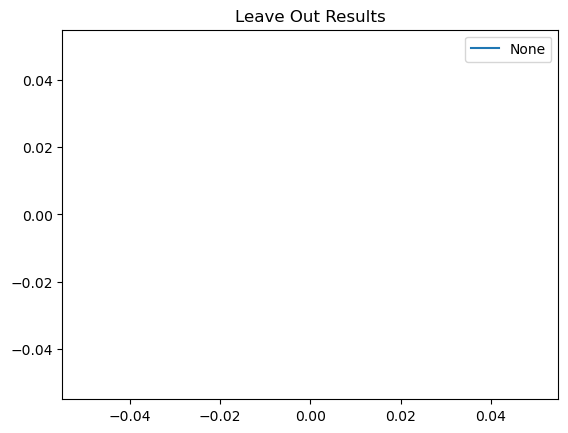

  Metric  RAGU_diff
0   None        0.0


In [25]:
leave_out_results_dict = dict()
waterfall_df = pd.DataFrame()
for leave_out in leave_out_list:
    RAGU_diff = np.abs(all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score).mean()
    waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    leave_out_results_dict[leave_out] = RAGU_diff
    plt.plot(all_leave_out_df.loc['None'].vintage.apply(vintage_to_float), all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score, label=leave_out)
plt.title("Leave Out Results")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
print(pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff'))
waterfall_df.index = all_leave_out_df.loc['None'].vintage
#waterfall_df

In [26]:
leave_out_df#[np.array(leave_out_df.reset_index().vintage.apply(vintage_to_float)>=2022)]

,index,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,only_recovery_ragu,ms_100_ltv,ragu_score,leave_out
vintage,,,,,,,,,,,,,,,,,,,,,,,
2024-01,non_kmxent,9862505.11,NaN,0.550383,1.555441,NaN,NaN,0.0,0.0,NaN,NaN,0.5,138.736473,138.271731,0.0,1.000697,0.0,138.736473,138.763083,0.02661,138.736473,138.736473,None
2024-02,non_kmxent,14078754.81,NaN,0.55413,1.522365,NaN,NaN,0.0,0.0,NaN,NaN,0.5,139.007048,138.492161,0.0,1.007509,0.0,139.007048,139.296261,0.289213,139.007048,139.007048,None
2024-03,non_kmxent,12572148.64,NaN,0.546553,1.536157,NaN,NaN,0.0,0.0,NaN,NaN,0.5,138.569363,137.995865,0.0,0.993733,0.0,138.569363,138.332034,-0.237329,138.569363,138.569363,None
2024-04,non_kmxent,14752713.35,NaN,0.546678,1.500433,NaN,NaN,0.0,0.0,NaN,NaN,0.5,139.347447,138.539904,0.0,0.99396,0.0,139.347447,139.117405,-0.230043,139.347447,139.347447,None
2024-05,non_kmxent,16273245.95,NaN,0.5433,1.553771,NaN,NaN,0.0,0.0,NaN,NaN,0.5,138.370137,138.015695,0.0,0.987819,0.0,138.370137,137.912272,-0.457865,138.370137,138.370137,None
2024-06,non_kmxent,17644353.16,NaN,0.551141,1.506416,NaN,NaN,0.0,0.0,NaN,NaN,0.5,138.704038,138.003575,0.0,1.002075,0.0,138.704038,138.783353,0.079315,138.704038,138.704038,None
2024-07,non_kmxent,19257321.46,NaN,0.542466,1.512263,NaN,NaN,0.0,0.0,NaN,NaN,0.5,138.460832,137.678591,0.0,0.986301,0.0,138.460832,137.946371,-0.514461,138.460832,138.460832,None
2024-08,non_kmxent,41658408.28,NaN,0.538989,1.532811,NaN,NaN,0.0,0.0,NaN,NaN,0.5,136.317186,136.443456,0.0,0.979981,0.0,136.317186,135.58174,-0.735447,136.317186,136.317186,None
2024-09,non_kmxent,38436376.62,NaN,0.542076,1.517222,NaN,NaN,0.0,0.0,NaN,NaN,0.5,137.082702,137.068936,0.0,0.985593,0.0,137.082702,136.547399,-0.535303,137.082702,137.082702,None


In [27]:
if granularity != 'w':
    leave_out_results_dict = dict()
    for leave_out in leave_out_list:
        plt_df = waterfall_df[np.array(waterfall_df.reset_index().vintage.apply(vintage_to_float)>=2020)].reset_index()
        if (np.abs(plt_df['None'] - plt_df[leave_out])).mean() < 0.05:
            continue
        plt.plot(plt_df.vintage.apply(vintage_to_float), smooth(np.abs(plt_df['None'] - plt_df[leave_out])), label=leave_out)
        leave_out_results_dict[leave_out] = np.abs(plt_df['None'] - plt_df[leave_out]).mean()
    plt.title("Leave Out Results")
    plt.legend(bbox_to_anchor=(1, 1))
    plt.show()
    pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

In [28]:
store_pickle(vintages_dict, 'vintages_dict_pickle')

In [29]:
pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

,Metric,RAGU_diff
0,None,0.0


# Export results to an Excel for manual inputs

In [30]:
import openpyxl
import pyodbc
import warnings
import pandas as pd
import datetime
import numpy as np
import re
import os
import copy

In [31]:
def excel_cell_to_index(cell_name):
    """
    Converts a cell name to its index; for example, 'B2' becomes (2, 2), since B is the second letter of the alphabet.
    """
    # Extract the column part from the cell name
    col_str = ''.join(filter(str.isalpha, cell_name)).upper()
    # Convert column letters to column index
    col_index = 0
    for i, char in enumerate(col_str):
        col_index = col_index * 26 + (ord(char) - ord('A')) + 1
    # Extract the row part from the cell name
    row_str = ''.join(filter(str.isdigit, cell_name))
    # Convert row string to row index
    row_index = int(row_str)
    return row_index, col_index
def overwrite_values(df, start_cell, worksheet):
    """
    Overwrites values in the given worksheet with the values in the given DataFrame, starting at the given cell name start_cell.
    """
    # Get the size of the DataFrame
    num_rows, num_cols = df.shape
    # Get starting cell indices
    start_cell_row, start_cell_col = excel_cell_to_index(start_cell)
    # Replace the data in the worksheet with the DataFrame
    for row in range(num_rows):
        for col in range(num_cols):
            cell = worksheet.cell(row=row+start_cell_row, column=col+start_cell_col)
            cell.value = df.iloc[row, col]
    return worksheet
def read_excel_selection(start_cell, end_cell, worksheet):
    """
    Converts a section of the worksheet to a Pandas DataFrame.
    """
    start_row, start_col = excel_cell_to_index(start_cell)
    end_row, end_col = excel_cell_to_index(end_cell)
    # Read data from the selected range into a list of lists
    data = []
    for row in range(start_row, end_row + 1):
        row_data = []
        for col in range(start_col, end_col + 1):
            cell = worksheet.cell(row=row, column=col)
            row_data.append(cell.value)
        data.append(row_data)
    return pd.DataFrame(data)
# This function returns the value contained within a given cell
excel_lookup = lambda cell: workbook[re.search(r'=(.*?)!', cell.value).group(1)][re.search(r'!(.*)', cell.value).group(1)]

In [32]:
# Be sure to rerun this code after hitting ctrl+s in the Excel document.
# Weekly uses different Excel file than quarterly/monthly
if use_app_date_vintage:
    workbook = openpyxl.load_workbook('weekly RAGU newrecovery.xlsx')
else:
    workbook = openpyxl.load_workbook('new_recovery_ragu.xlsx')

# Save Data Tables

### NonKMXENT

In [33]:
worksheet = workbook[f'Data Tables ({granularity.upper()})']

In [34]:
worksheet

<Worksheet "Data Tables (W)">

In [35]:
if granularity != 'w':
    for lob, cell in zip(('AN', 'FRN', 'STG', 'non_kmxent'), ('B2', 'B20', 'B29', 'B47')):
        result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
        result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
        result_df = result_yearly_df.drop('amt_financed_x')
        for year in range(2016, 2020):
            year = str(year)
            metric_dict = dict()
            if granularity=='q':
                vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)]
            elif granularity == 'm':
                vintages_in_year = [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
            
            for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
                metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
            result_yearly_df[year] = pd.Series(metric_dict)
        result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
        result_yearly_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
        result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
        result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
        full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
        differences_df = full_result_df.copy()
        differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
        differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
        differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
        differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
        differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
        differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
        differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
        xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
        worksheet = overwrite_values(xlsx_df, cell, worksheet)
else:
    # Weekly mode - no historical yearly aggregation
    for lob, cell in zip(('AN', 'FRN', 'STG', 'non_kmxent'), ('B2', 'B20', 'B29', 'B47')):
        result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
        result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
        result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
        full_result_df = result_df.copy()
        differences_df = full_result_df.copy()
        differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
        differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
        differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
        differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
        differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
        differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
        differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
        xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
        worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [36]:
correct_vintage_order = list(xlsx_df.columns)

### ENT, FLD

In [37]:
if granularity != 'w':
    for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
        result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
        result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
        result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
        result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
        full_result_df = result_df.copy()
        differences_df = full_result_df.copy()
        differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
        differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
        differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
        differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
        differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
        differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
        differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
        xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
        worksheet = overwrite_values(xlsx_df, cell, worksheet)
else:
    # Weekly mode - different cell positions (B38, B11 instead of F38, F11)
    for lob, cell in zip(('ENT', 'FLD'), ('B38', 'B11')):
        result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
        result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
        result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
        full_result_df = result_df.copy()
        differences_df = full_result_df.copy()
        differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
        differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
        differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
        differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
        differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
        differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
        differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
        xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
        worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [38]:
# for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
#     result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
#     result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
#     result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
#     result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
#     full_result_df = result_df.copy()
#     differences_df = full_result_df.copy()
#     differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
#     differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
#     differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
#     differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
#     differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
#     differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
#     differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
#     xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T

In [39]:
# scratch = all_df_no_dropout.loc['ENT'][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']]#.reset_index(drop=True).set_index('vintage').T.copy()
# scratch.to_csv("scratch.csv")

### KMX

In [40]:
if granularity != 'w':
    lob = 'KMX'
    result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
    result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df = result_yearly_df.drop('amt_financed_x')
    for year in range(2016, 2020):
        year = str(year)
        metric_dict = dict()
        vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
        for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
            metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
        result_yearly_df[year] = pd.Series(metric_dict)
    result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
    result_yearly_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
    differences_df = full_result_df.copy()
    differences_df.loc['Mountain3 Score'] = full_result_df.loc['Mountain3 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Mountain3 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    xlsx_df = xlsx_df[correct_vintage_order]
    print(xlsx_df)
    worksheet = overwrite_values(xlsx_df, 'B56', worksheet)
else:
    # Weekly mode - no historical yearly aggregation
    lob = 'KMX'
    result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
    result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    full_result_df = result_df.copy()
    differences_df = full_result_df.copy()
    differences_df.loc['Mountain3 Score'] = full_result_df.loc['Mountain3 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Mountain3 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, 'B56', worksheet)

### POS

In [41]:
if granularity != 'w':
    lob = 'POS'
    result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
    result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df = result_yearly_df.drop('amt_financed_x')
    for year in range(2016, 2020):
        year = str(year)
        metric_dict = dict()
        vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
        for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
            metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
        result_yearly_df[year] = pd.Series(metric_dict)
    result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
    result_yearly_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
    differences_df = full_result_df.copy()
    differences_df.loc['Modern Score'] = full_result_df.loc['Modern Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Modern Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, 'B65', worksheet)
else:
    # Weekly mode - no historical yearly aggregation
    lob = 'POS'
    result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
    result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    full_result_df = result_df.copy()
    differences_df = full_result_df.copy()
    differences_df.loc['Modern Score'] = full_result_df.loc['Modern Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Modern Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, 'B65', worksheet)

# Distribution Data

In [42]:
with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    with open("distribution_query_temp.txt", "r") as file:
        temp_table_queries = file.read()
        conn.execute(temp_table_queries.strip())
        distribution_df = run_sql('distribution_query_current.txt', connection=conn)
distribution_df  = distribution_df.pivot(index = 'roa_dealer_group',columns = 'vintage', values = 'distribution')

worksheet = worksheet = workbook['distribution_rolledup']
worksheet = overwrite_values(distribution_df,'B3', worksheet)

KeyError: 'Worksheet distribution_rolledup does not exist.'

In [43]:
distribution_df.to_csv('dist_df.csv')

# $t_{-1}$ Table

In [44]:
worksheet = workbook['t-1 Data Table']
run_query = False
if run_query or run_every_query:
    t_1_table = run_sql('select * from sandbox.t_1', filename_is_query=True)
    store_pickle(t_1_table, 't_1_table_pickle')
else:
    t_1_table = get_pickle('t_1_table_pickle')
latest_t_1 = pd.DataFrame(columns=t_1_table.columns)
for lob in t_1_table.roa_dealer_group.unique():
    latest_t_1 = pd.concat([latest_t_1, t_1_table[t_1_table['lookup']==(lob+str(t_1_table[t_1_table.roa_dealer_group==lob].rowid.max()))]])
latest_t_1 = latest_t_1.sort_values('lookup').set_index('roa_dealer_group').loc[['AN', 'ENT', 'FLD', 'FRN', 'KMX', 'STG']]
worksheet = overwrite_values(latest_t_1, 'B2', worksheet)

# Put Leave Out Analysis Waterfalls in Excel

In [45]:
worksheet = workbook['Waterfall Tables']
waterfall_df_dict = dict()
for lob, cell, lob_type in zip(['AN', 'FRN', 'STG', 'FLD', 'KMX', 'ENT'], 
                     ['B3', 'B48', 'B92', 'B135', 'B190', 'B164'],
                     ['non_kmxent']*4+['KMX', 'ENT']):
    all_leave_out_df = pd.DataFrame()
    for leave_out in leave_out_list:
        leave_out_df = pd.DataFrame()
        for i in full_df_list_dict_dict[leave_out][lob_type]:
            if (lob=='FLD' and 'FLD' not in i.index) or (lob=='ENT' and 'ENT' not in i.index):
                continue
            leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc[lob]).T])
        leave_out_df['leave_out'] = leave_out
        leave_out_df = leave_out_df.reset_index().set_index('vintage')
        all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
    all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

    waterfall_df = pd.DataFrame()
    for leave_out in leave_out_list:
        waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    waterfall_df.index = all_leave_out_df.loc['None'].vintage
    waterfall_df_dict[lob] = waterfall_df
    worksheet = overwrite_values(waterfall_df, cell, worksheet)

In [46]:
for lob, lob_type in zip(['FLD'], 
                        ['non_kmxent']):
    all_leave_out_df = pd.DataFrame()
    for leave_out in leave_out_list:
        leave_out_df = pd.DataFrame()
        for i in full_df_list_dict_dict[leave_out][lob_type]:
            if (lob=='FLD' and 'FLD' not in i.index) or (lob=='ENT' and 'ENT' not in i.index):
                continue
            leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc[lob]).T])
        leave_out_df['leave_out'] = leave_out
        leave_out_df = leave_out_df.reset_index().set_index('vintage')
        all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
    all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

    waterfall_df = pd.DataFrame()
    for leave_out in leave_out_list:
        waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    waterfall_df.index = all_leave_out_df.loc['None'].vintage
    waterfall_df_dict[lob] = waterfall_df
    waterfall_df.to_csv('waterfallFLD.csv')

In [47]:
# Weekly saves to different Excel file than quarterly/monthly
if use_app_date_vintage:
    workbook.save('weekly RAGU newrecovery.xlsx')
else:
    workbook.save('cursor_ragu.xlsx')

In [ ]:
mmi_lookup_df = pd.read_csv('../../Downloads/mmi_index_2019seasonality.csv').rename(columns={'mmi_2019_seasonality_index':'mmi'})
mmi_lookup_df['month'] = mmi_lookup_df.month_start.astype(str).str[:4] + '-' + mmi_lookup_df.month_start.astype(str).str[4:6]
mmi_lookup_df = mmi_lookup_df.drop(columns='month_start')
mmi_lookup_df

In [ ]:
pd.__version__

In [ ]:
pd.get_option('mode.copy_on_write')

In [ ]:
all_leave_out_df

In [ ]:
scratch = ula_df_total.loc[(ula_df_total['lob']=='KMX') & (ula_df_total['vintage']=='2025 M02')]
scratch.head()